# Customer Investment Needs — Modeling

Train binary classifiers for each investment target, build an entropy-gated stacking ensemble, and flag uncertain predictions for advisor review.

---

## Notebook Structure

1. Imports & Setup
2. Load Processed Data
3. Train / Test Split
4. Scaling
5. Distance Matrix Construction
6. Model Evaluation Strategy
7. Modeling
8. Entropy-Gated Ensemble
9. Recommendations
10. Export

---
## 1. Imports & Setup

In [64]:
import importlib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import models as model_module
import plots
import utilities
from models import ModelFactory
from plots import *
from utilities import *

# Hot-reload during development
importlib.reload(plots)
importlib.reload(utilities)
importlib.reload(model_module)

sns.set_theme(style="darkgrid", context="notebook", palette="muted")
plt.rcParams.update({
    "figure.dpi":       110,
    "axes.titlesize":   12,
    "axes.labelsize":   10,
    "figure.facecolor": "#1a1a2e",
    "axes.facecolor":   "#16213e",
    "text.color":       "#e0e0e0",
    "axes.labelcolor":  "#e0e0e0",
    "xtick.color":      "#e0e0e0",
    "ytick.color":      "#e0e0e0",
})

SEED    = 42
TARGETS = ["IncomeInvestment", "AccumulationInvestment"]

---
## 2. Load Processed Data

Loads two sheets from `processed_features.xlsx`: `features` (engineered inputs) and `targets` (two binary labels).

In [65]:
input_path = "processed_features.xlsx"

feature_df = pd.read_excel(input_path, sheet_name="features", index_col=0)
targets_df = pd.read_excel(input_path, sheet_name="targets",  index_col=0)

print("features :", feature_df.shape)
print("targets  :", targets_df.shape)
print("\nClass balance:")
print(targets_df.mean().round(3))
feature_df.head()

features : (5000, 9)
targets  : (5000, 2)

Class balance:
IncomeInvestment          0.384
AccumulationInvestment    0.513
dtype: float64


,Age,FamilyMembers,FinancialEducation,RiskPropensity,Wealth_log,Income_log,IncomePerFamilyMember_log,Income_Wealth_Ratio_log,IncomeDivAge
0,60,2,0.317417,0.416527,5.006400,4.097304,3.420638,0.335660,0.986297
1,59,1,0.522121,0.305055,2.215342,2.214283,2.214283,0.692553,0.138218
2,56,2,0.354579,0.388738,4.114590,3.474143,2.811514,0.418187,0.558396
3,46,2,0.710072,0.785446,3.949542,4.378311,3.697632,0.934477,1.710941
4,71,4,0.666237,0.493797,6.234685,5.711361,4.334942,0.464832,4.243412


In [66]:
NUMERICAL_FEATURES   = feature_df.select_dtypes(include="number").columns.tolist()
CATEGORICAL_FEATURES = feature_df.select_dtypes(exclude="number").columns.tolist()

print("Numerical  :", NUMERICAL_FEATURES)
print("Categorical:", CATEGORICAL_FEATURES)

Numerical  : ['Age', 'FamilyMembers', 'FinancialEducation', 'RiskPropensity', 'Wealth_log', 'Income_log', 'IncomePerFamilyMember_log', 'Income_Wealth_Ratio_log', 'IncomeDivAge']
Categorical: []


---
## 3. Train / Test Split

Stratified 80/20 split applied once before any scaling. Stratification preserves class balance across both sets.

> **Leakage note:** The scaler is fit on `X_train` only (§4). The distance matrix (§5) also uses training features exclusively.

In [67]:
income_series = targets_df["IncomeInvestment"]
accum_series  = targets_df["AccumulationInvestment"]

X_train_inc, X_test_inc, y_income_train, y_income_test = train_test_split(
    feature_df, income_series,
    test_size=0.2, random_state=SEED, stratify=income_series,
)

X_train_acc, X_test_acc, y_accum_train, y_accum_test = train_test_split(
    feature_df, accum_series,
    test_size=0.2, random_state=SEED, stratify=accum_series,
)

print(f"Income       — train: {len(X_train_inc):,}  test: {len(X_test_inc):,}")
print(f"Accumulation — train: {len(X_train_acc):,}  test: {len(X_test_acc):,}")

Income       — train: 4,000  test: 1,000
Accumulation — train: 4,000  test: 1,000


---
## 4. Scaling

`StandardScaler` fit on training data only, then applied to both splits. Fitting on the full dataset before splitting would leak test statistics.

In [68]:
# 1. Scalers (separate per target)
scaler_inc = StandardScaler()
scaler_acc = StandardScaler()

# 2. Income scaling
X_train_inc_scaled = pd.DataFrame(
    scaler_inc.fit_transform(X_train_inc[NUMERICAL_FEATURES]),
    columns=NUMERICAL_FEATURES,
    index=X_train_inc.index
)
X_test_inc_scaled = pd.DataFrame(
    scaler_inc.transform(X_test_inc[NUMERICAL_FEATURES]),
    columns=NUMERICAL_FEATURES,
    index=X_test_inc.index
)
for col in CATEGORICAL_FEATURES:
    X_train_inc_scaled[col] = X_train_inc[col].values
    X_test_inc_scaled[col]  = X_test_inc[col].values

# 3. Accumulation scaling
X_train_acc_scaled = pd.DataFrame(
    scaler_acc.fit_transform(X_train_acc[NUMERICAL_FEATURES]),
    columns=NUMERICAL_FEATURES,
    index=X_train_acc.index
)
X_test_acc_scaled = pd.DataFrame(
    scaler_acc.transform(X_test_acc[NUMERICAL_FEATURES]),
    columns=NUMERICAL_FEATURES,
    index=X_test_acc.index
)
for col in CATEGORICAL_FEATURES:
    X_train_acc_scaled[col] = X_train_acc[col].values
    X_test_acc_scaled[col]  = X_test_acc[col].values

# 4. Sanity checks
print("Income train means (should be ~0):")
print(X_train_inc_scaled[NUMERICAL_FEATURES].mean().round(3))
print("\nAccumulation train means (should be ~0):")
print(X_train_acc_scaled[NUMERICAL_FEATURES].mean().round(3))

Income train means (should be ~0):
Age                          0.0
FamilyMembers               -0.0
FinancialEducation           0.0
RiskPropensity              -0.0
Wealth_log                  -0.0
Income_log                   0.0
IncomePerFamilyMember_log   -0.0
Income_Wealth_Ratio_log     -0.0
IncomeDivAge                -0.0
dtype: float64

Accumulation train means (should be ~0):
Age                          0.0
FamilyMembers                0.0
FinancialEducation           0.0
RiskPropensity              -0.0
Wealth_log                   0.0
Income_log                   0.0
IncomePerFamilyMember_log   -0.0
Income_Wealth_Ratio_log      0.0
IncomeDivAge                 0.0
dtype: float64


---
## 5. Distance Matrix Construction

Euclidean distance matrix built on training features only. Used downstream in the KNN uncertainty step — test-set geometry must not influence it.

In [69]:
distance_matrix = pairwise_distances(X_train_inc_scaled, metric="euclidean")

print(f"Distance matrix shape : {distance_matrix.shape}")
print(f"Value range           : [{distance_matrix.min():.4f}, {distance_matrix.max():.4f}]")
print(f"Mean distance         : {distance_matrix.mean():.4f}")

assert np.allclose(np.diag(distance_matrix), 0, atol=1e-6), "Diagonal non-zero."
print("Diagonal check        : OK")

Distance matrix shape : (4000, 4000)
Value range           : [0.0000, 21.0259]
Mean distance         : 3.8996
Diagonal check        : OK


---
## 6. Model Evaluation Strategy

Three-metric framework — accuracy alone is insufficient given class imbalance and asymmetric error costs:

| Metric | Type | Role |
|--------|------|------|
| Recall(class 0) ≥ 0.90 | Hard constraint | Rejects models that pass too many bad recommendations |
| Safety-Constrained Precision | Primary | Quality metric among safe models |
| Balanced Business Score | Secondary | Coverage vs. precision trade-off |

---
## 7. Modeling

`run_experiment` runs a leakage-safe pipeline per model: optional tuning → cross-validation on `X_train` → final fit on full `X_train` → evaluation on `X_test`.

### 7.1 Logistic Regression
Linear baseline. Interpretable calibration reference for the ensemble.

---

### 7.2 XGBoost
Gradient-boosted trees. Strongest nonlinear learner; primary ensemble contributor.

---

### 7.3 K-Nearest Neighbors (KNN)
Distance-based; captures local structure missed by global models. Sensitive to dimensionality.

---

### 7.4 Support Vector Machine (SVM)
Margin-based classifier. Effective in medium-dimensional spaces; sensitive to scaling.

---

### 7.5 Gaussian Naive Bayes
Probabilistic baseline assuming feature independence. Fast and stable but limited on complex interactions.


TUNING SUMMARY
+---------------+--------------------+
|    Metric     |       Value        |
+---------------+--------------------+
|     Model     | LogisticRegression |
| Best CV Score |       0.644        |
|  Best Params  |      C: 0.01       |
|               |    penalty: l1     |
|               | solver: liblinear  |
+---------------+--------------------+

LogisticRegression — Income
+-----------------+---------+--------+---------------+
|     Metric      | CV Mean | CV Std |   Test Set    |
+-----------------+---------+--------+---------------+
|    Accuracy     |  0.763  | 0.015  |     0.757     |
| Precision (0/1) |  0.755  | 0.031  | 0.763 / 0.742 |
|  Recall (0/1)   |  0.733  |  0.13  | 0.878 / 0.562 |
|    F1 (0/1)     |  0.74   |  0.08  | 0.817 / 0.640 |
|     Safety      |  -1.0   |  0.0   |     -1.0      |
|    Balanced     |  0.642  | 0.017  |     0.616     |
+-----------------+---------+--------+---------------+


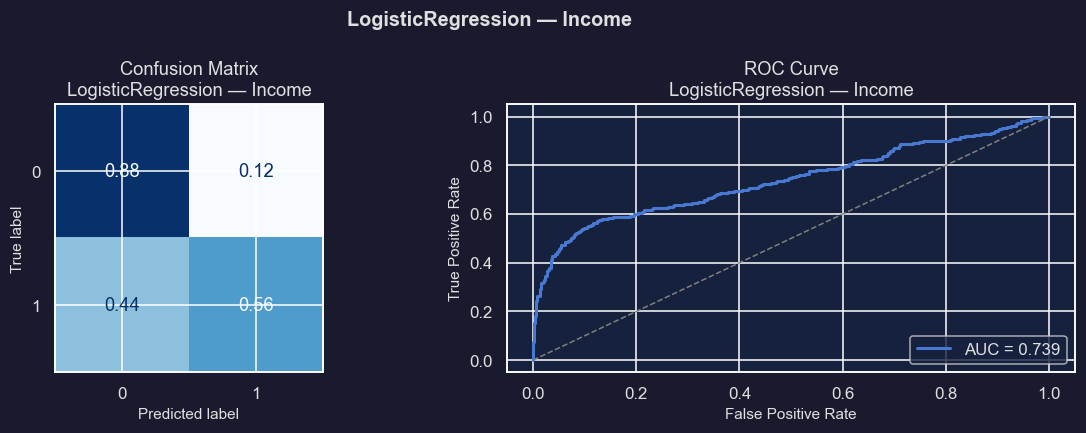


TUNING SUMMARY
+---------------+--------------------+
|    Metric     |       Value        |
+---------------+--------------------+
|     Model     | LogisticRegression |
| Best CV Score |       0.6891       |
|  Best Params  |       C: 0.1       |
|               |    penalty: l2     |
|               | solver: liblinear  |
+---------------+--------------------+

LogisticRegression — Accumulation
+-----------------+---------+--------+---------------+
|     Metric      | CV Mean | CV Std |   Test Set    |
+-----------------+---------+--------+---------------+
|    Accuracy     |  0.658  | 0.011  |     0.686     |
| Precision (0/1) |  0.659  | 0.012  | 0.684 / 0.687 |
|  Recall (0/1)   |  0.657  | 0.043  | 0.659 / 0.712 |
|    F1 (0/1)     |  0.657  | 0.023  | 0.672 / 0.699 |
|     Safety      |  -1.0   |  0.0   |     -1.0      |
|    Balanced     |  0.685  | 0.016  |     0.704     |
+-----------------+---------+--------+---------------+


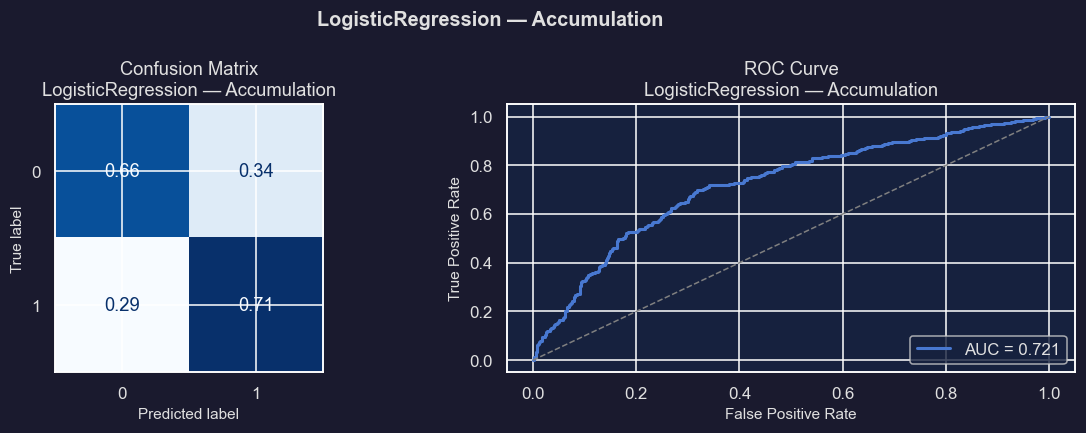


TUNING SUMMARY
+---------------+--------------------------------------+
|    Metric     |                Value                 |
+---------------+--------------------------------------+
|     Model     |               XGBoost                |
| Best CV Score |                0.6925                |
|  Best Params  | colsample_bytree: 0.9777389931549642 |
|               |       gamma: 3.50310722310683        |
|               |  learning_rate: 0.13615867129890064  |
|               |             max_depth: 4             |
|               |         min_child_weight: 4          |
|               |          n_estimators: 185           |
|               |   reg_alpha: 0.0003052537633674302   |
|               |    reg_lambda: 0.5512783985900913    |
|               |    subsample: 0.7971894567956928     |
+---------------+--------------------------------------+

XGBoost — Income
+-----------------+---------+--------+---------------+
|     Metric      | CV Mean | CV Std |   Test Set    |
+

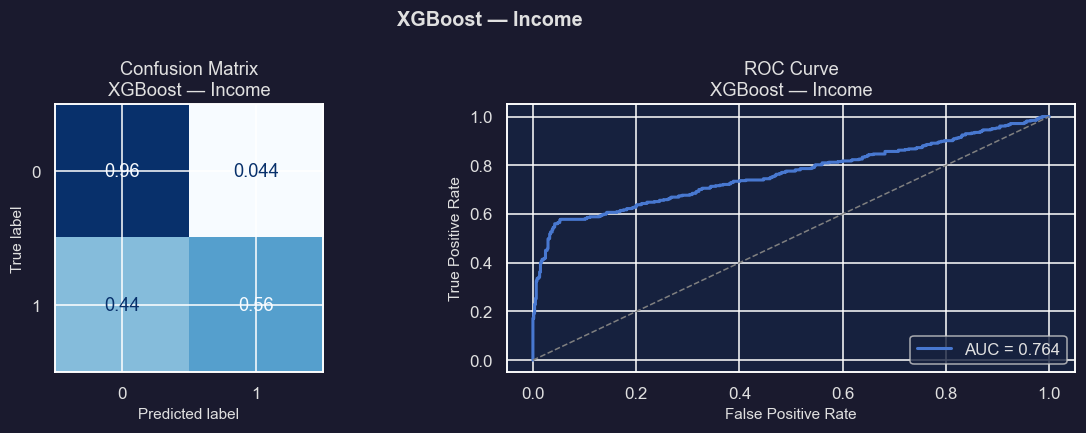


TUNING SUMMARY
+---------------+--------------------------------------+
|    Metric     |                Value                 |
+---------------+--------------------------------------+
|     Model     |               XGBoost                |
| Best CV Score |                0.7991                |
|  Best Params  | colsample_bytree: 0.9777389931549642 |
|               |       gamma: 3.50310722310683        |
|               |  learning_rate: 0.13615867129890064  |
|               |             max_depth: 4             |
|               |         min_child_weight: 4          |
|               |          n_estimators: 185           |
|               |   reg_alpha: 0.0003052537633674302   |
|               |    reg_lambda: 0.5512783985900913    |
|               |    subsample: 0.7971894567956928     |
+---------------+--------------------------------------+

XGBoost — Accumulation
+-----------------+---------+--------+---------------+
|     Metric      | CV Mean | CV Std |   Test Set 

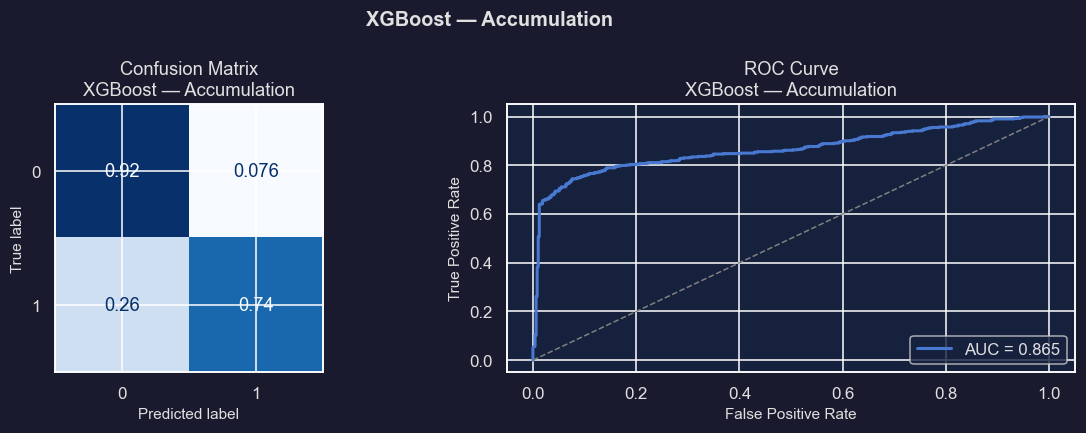


TUNING SUMMARY
+---------------+-------------------+
|    Metric     |       Value       |
+---------------+-------------------+
|     Model     |        KNN        |
| Best CV Score |      0.6343       |
|  Best Params  | metric: manhattan |
|               |  n_neighbors: 11  |
|               | weights: distance |
+---------------+-------------------+

KNN — Income
+-----------------+---------+--------+---------------+
|     Metric      | CV Mean | CV Std |   Test Set    |
+-----------------+---------+--------+---------------+
|    Accuracy     |  0.778  | 0.008  |     0.753     |
| Precision (0/1) |  0.784  |  0.02  | 0.746 / 0.775 |
|  Recall (0/1)   |  0.738  | 0.173  | 0.909 / 0.503 |
|    F1 (0/1)     |  0.748  | 0.087  | 0.819 / 0.610 |
|     Safety      |  0.445  | 0.723  |     0.775     |
|    Balanced     |  0.635  | 0.012  |     0.584     |
+-----------------+---------+--------+---------------+


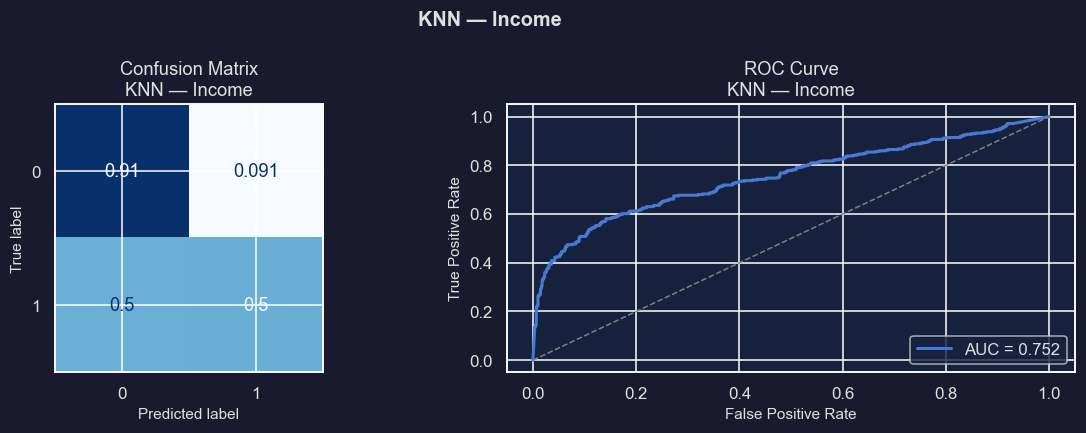


TUNING SUMMARY
+---------------+-------------------+
|    Metric     |       Value       |
+---------------+-------------------+
|     Model     |        KNN        |
| Best CV Score |       0.743       |
|  Best Params  | metric: manhattan |
|               |  n_neighbors: 24  |
|               | weights: distance |
+---------------+-------------------+

KNN — Accumulation
+-----------------+---------+--------+---------------+
|     Metric      | CV Mean | CV Std |   Test Set    |
+-----------------+---------+--------+---------------+
|    Accuracy     |  0.754  | 0.017  |     0.758     |
| Precision (0/1) |  0.756  | 0.033  | 0.730 / 0.790 |
|  Recall (0/1)   |  0.755  | 0.039  | 0.799 / 0.719 |
|    F1 (0/1)     |  0.754  | 0.018  | 0.763 / 0.753 |
|     Safety      |  -1.0   |  0.0   |     -1.0      |
|    Balanced     |  0.739  | 0.019  |     0.741     |
+-----------------+---------+--------+---------------+


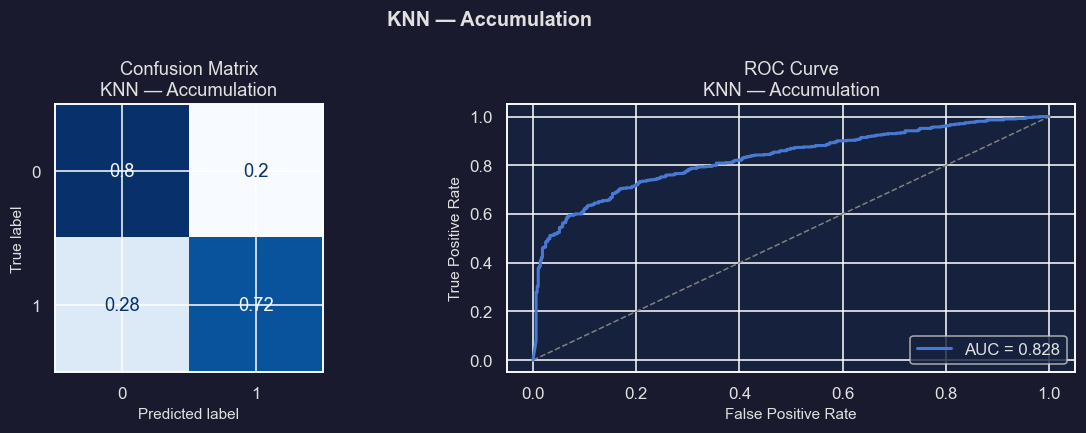


TUNING SUMMARY
+---------------+-----------------------+
|    Metric     |         Value         |
+---------------+-----------------------+
|     Model     |          SVM          |
| Best CV Score |         0.642         |
|  Best Params  | C: 2.9397976202716882 |
|               |      gamma: auto      |
|               |      kernel: rbf      |
+---------------+-----------------------+

SVM — Income
+-----------------+---------+--------+---------------+
|     Metric      | CV Mean | CV Std |   Test Set    |
+-----------------+---------+--------+---------------+
|    Accuracy     |  0.786  | 0.009  |     0.776     |
| Precision (0/1) |  0.803  | 0.038  | 0.757 / 0.836 |
|  Recall (0/1)   |  0.742  | 0.191  | 0.937 / 0.518 |
|    F1 (0/1)     |  0.754  |  0.09  | 0.837 / 0.640 |
|     Safety      |  0.836  | 0.024  |     0.836     |
|    Balanced     |  0.636  | 0.015  |     0.614     |
+-----------------+---------+--------+---------------+


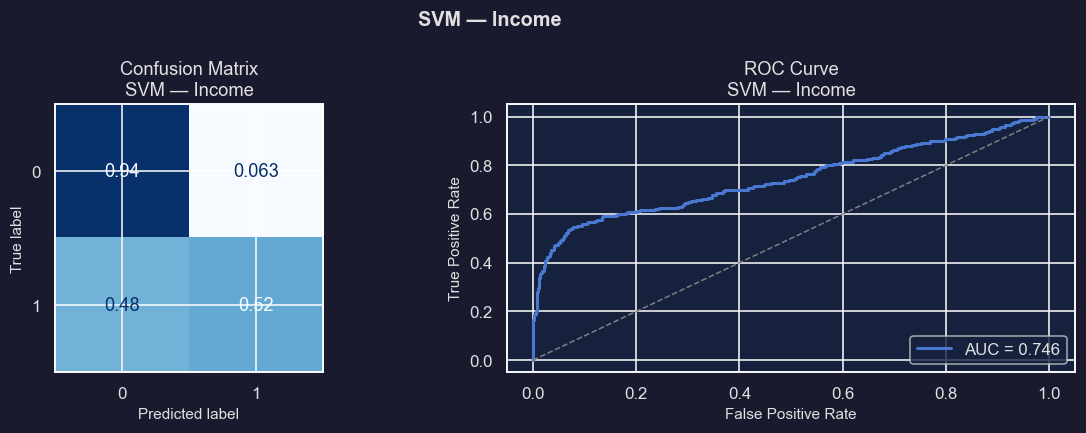


TUNING SUMMARY
+---------------+-------------------------+
|    Metric     |          Value          |
+---------------+-------------------------+
|     Model     |           SVM           |
| Best CV Score |         0.8155          |
|  Best Params  | C: 0.010340016434251914 |
|               |       gamma: auto       |
|               |      kernel: poly       |
+---------------+-------------------------+

SVM — Accumulation
+-----------------+---------+--------+---------------+
|     Metric      | CV Mean | CV Std |   Test Set    |
+-----------------+---------+--------+---------------+
|    Accuracy     |  0.598  | 0.004  |     0.598     |
| Precision (0/1) |  0.663  | 0.097  | 0.761 / 0.566 |
|  Recall (0/1)   |  0.589  | 0.334  | 0.255 / 0.924 |
|    F1 (0/1)     |  0.542  |  0.16  | 0.382 / 0.702 |
|     Safety      |  -1.0   |  0.0   |     -1.0      |
|    Balanced     |  0.816  | 0.007  |     0.817     |
+-----------------+---------+--------+---------------+


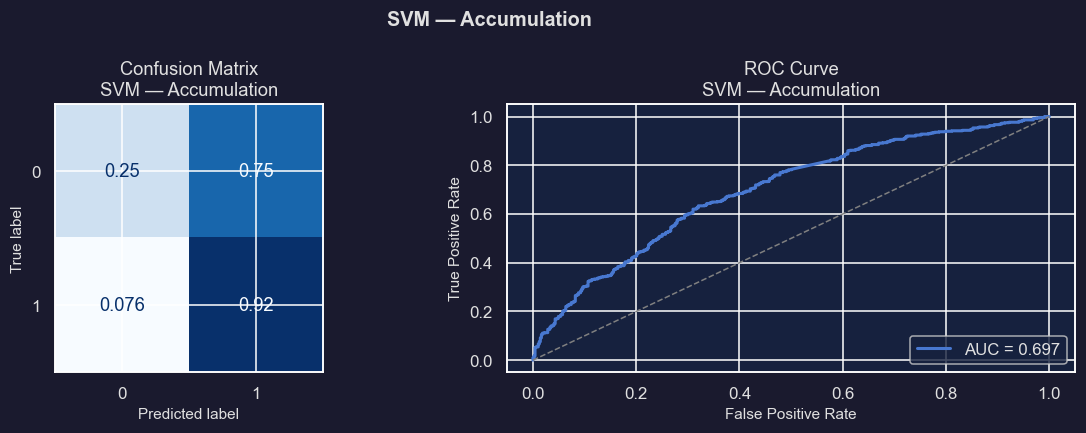


TUNING SUMMARY
+---------------+----------------------+
|    Metric     |        Value         |
+---------------+----------------------+
|     Model     |      GaussianNB      |
| Best CV Score |        0.6462        |
|  Best Params  | var_smoothing: 1e-11 |
+---------------+----------------------+

GaussianNB — Income
+-----------------+---------+--------+---------------+
|     Metric      | CV Mean | CV Std |   Test Set    |
+-----------------+---------+--------+---------------+
|    Accuracy     |  0.729  | 0.021  |     0.709     |
| Precision (0/1) |  0.714  |  0.07  | 0.758 / 0.626 |
|  Recall (0/1)   |  0.714  | 0.071  | 0.776 / 0.602 |
|    F1 (0/1)     |  0.714  | 0.069  | 0.767 / 0.614 |
|     Safety      |  -1.0   |  0.0   |     -1.0      |
|    Balanced     |  0.647  | 0.016  |     0.609     |
+-----------------+---------+--------+---------------+


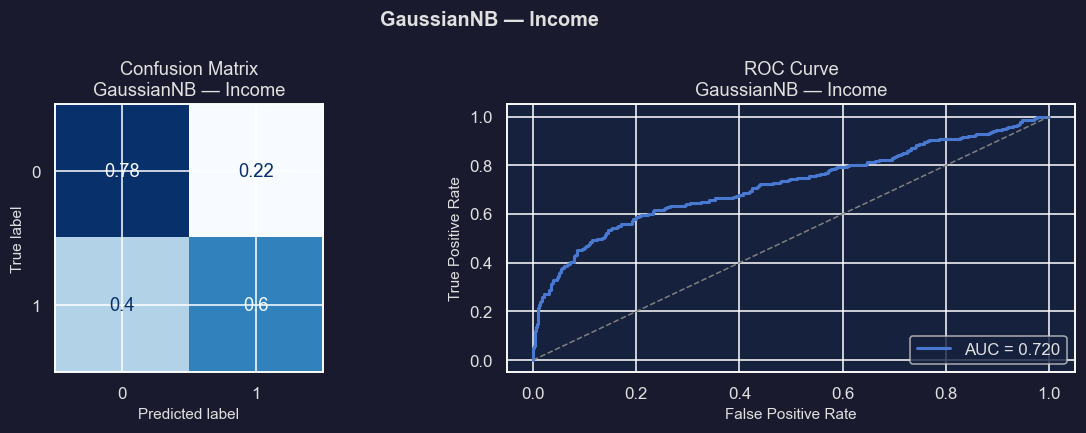


TUNING SUMMARY
+---------------+----------------------+
|    Metric     |        Value         |
+---------------+----------------------+
|     Model     |      GaussianNB      |
| Best CV Score |        0.6492        |
|  Best Params  | var_smoothing: 1e-11 |
+---------------+----------------------+

GaussianNB — Accumulation
+-----------------+---------+--------+---------------+
|     Metric      | CV Mean | CV Std |   Test Set    |
+-----------------+---------+--------+---------------+
|    Accuracy     |  0.641  | 0.012  |     0.655     |
| Precision (0/1) |  0.641  | 0.017  | 0.637 / 0.674 |
|  Recall (0/1)   |  0.641  | 0.023  | 0.678 / 0.634 |
|    F1 (0/1)     |  0.641  | 0.016  | 0.657 / 0.653 |
|     Safety      |  -1.0   |  0.0   |     -1.0      |
|    Balanced     |  0.649  | 0.016  |     0.646     |
+-----------------+---------+--------+---------------+


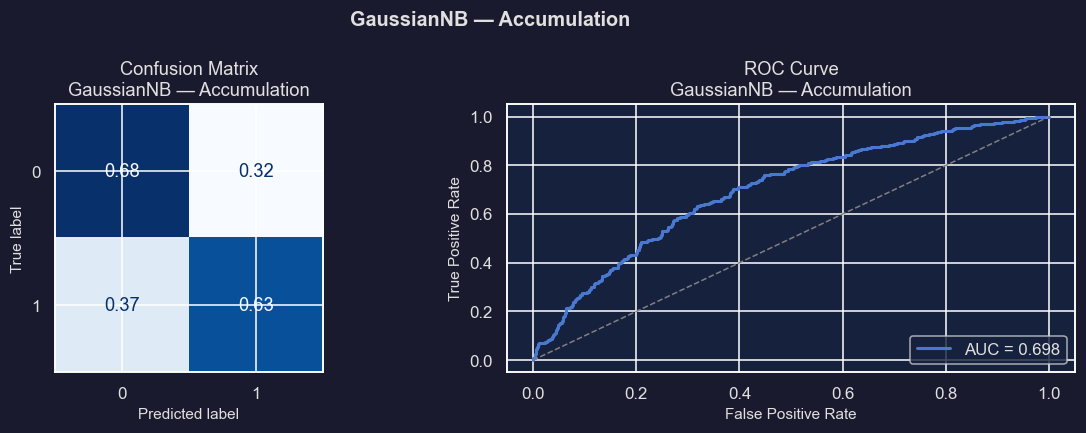


✔ Completed all experiments

Models trained:
 - logistic_income
 - logistic_accum
 - xgb_income
 - xgb_accum
 - knn_income
 - knn_accum
 - svm_income
 - svm_accum
 - gnb_income
 - gnb_accum

Income models: ['logistic', 'xgb', 'knn', 'svm', 'gnb']
Accum models: ['logistic', 'xgb', 'knn', 'svm', 'gnb']


In [70]:

# MODEL REGISTRY (ADD / REMOVE MODELS HERE)
MODEL_LIST = [
        #      "sgd",
              "logistic",
              "xgb",
              "knn",
              "svm",
              "gnb"
]

# STORAGE
model_outputs_income = []
model_outputs_accum = []

# RUN ALL EXPERIMENTS

trained_models = {}

for model_name in MODEL_LIST:

    # INCOME

    inc_model, inc_results, inc_train_prob, inc_test_prob, inc_preds = run_experiment(
        model_name, "Income",
        X_train_inc_scaled, y_income_train,
        X_test_inc_scaled, y_income_test,
        tune=True
    )

    # ACCUMULATION

    acc_model, acc_results, acc_train_prob, acc_test_prob, acc_preds = run_experiment(
        model_name, "Accumulation",
        X_train_acc_scaled, y_accum_train,
        X_test_acc_scaled, y_accum_test,
        tune=True
    )

    # STORE MODELS

    trained_models[f"{model_name}_income"] = inc_model
    trained_models[f"{model_name}_accum"] = acc_model

    # BUILD STRUCTURES (FOR ENSEMBLING)

    model_outputs_income.append({
        "name": model_name,
        "train_prob": np.asarray(inc_train_prob),
        "test_prob": np.asarray(inc_test_prob),
        "y_train": y_income_train.values,
        "y_test": y_income_test.values,
    })

    model_outputs_accum.append({
        "name": model_name,
        "train_prob": np.asarray(acc_train_prob),
        "test_prob": np.asarray(acc_test_prob),
        "y_train": y_accum_train.values,
        "y_test": y_accum_test.values,
    })



# FINAL OUTPUT STRUCTURE

print("\n✔ Completed all experiments")

print("\nModels trained:")
for k in trained_models:
    print(" -", k)

print("\nIncome models:", [m["name"] for m in model_outputs_income])
print("Accum models:", [m["name"] for m in model_outputs_accum])

#### Feature Importance

Top features driving predictions for each model.


--- Income Model: xgb ---


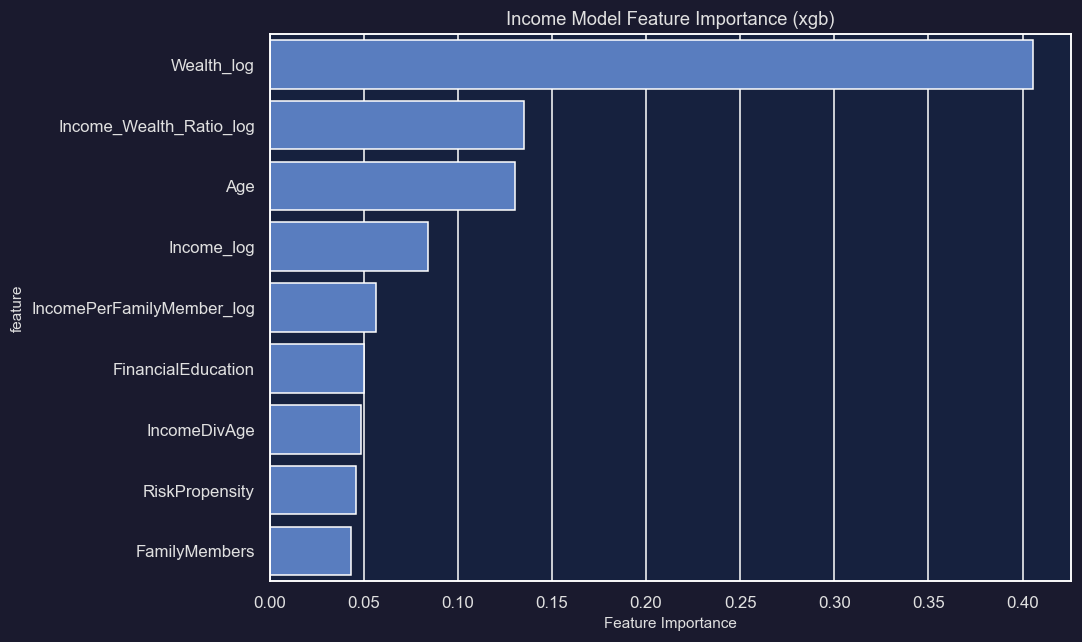


--- Accumulation Model: xgb ---


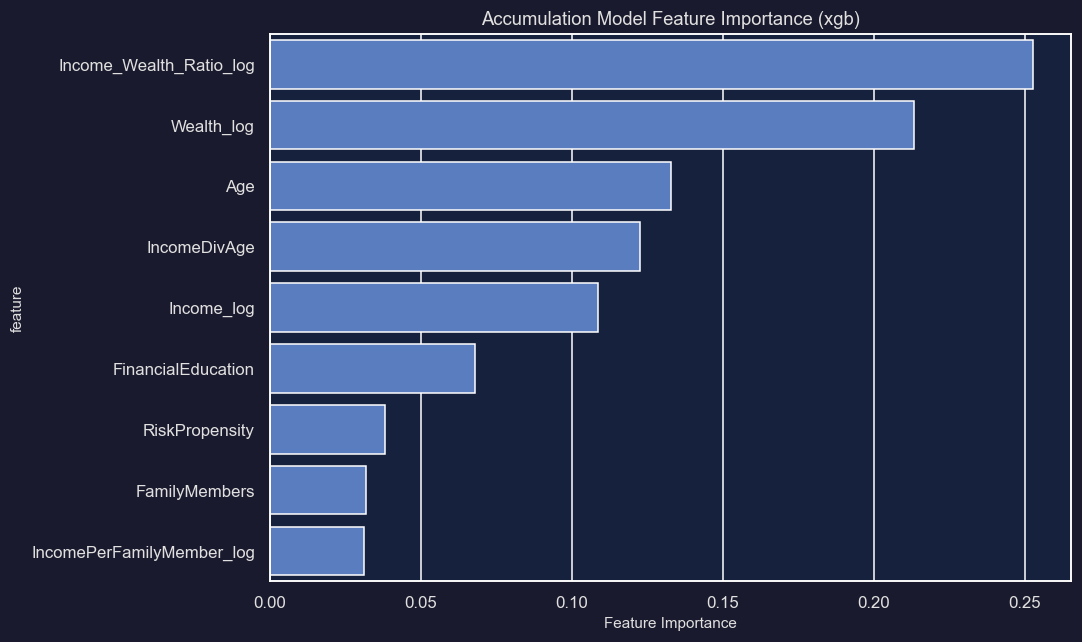

In [71]:
MODEL_LIST_feature_importance = ["xgb"]
# FEATURE IMPORTANCE PLOTTING (INCOME)

for model_name in MODEL_LIST_feature_importance:
    key = f"{model_name}_income"
    model = trained_models[key]
    print(f"\n--- Income Model: {model_name} ---")
    plot_feature_importance(model,X_train_inc_scaled.columns,f"Income Model Feature Importance ({model_name})")


# FEATURE IMPORTANCE PLOTTING (ACCUMULATION)

for model_name in MODEL_LIST_feature_importance:

    key = f"{model_name}_accum"
    model = trained_models[key]

    print(f"\n--- Accumulation Model: {model_name} ---")

    plot_feature_importance(
        model,
        X_train_acc_scaled.columns,
        f"Accumulation Model Feature Importance ({model_name})"
    )

#### Entropy Diagnostics

$H = -p\log_2 p - (1-p)\log_2(1-p)$ quantifies prediction uncertainty.

- **Train set** — top 5% highest-entropy samples flagged for potential relabelling.
- **Test set** — validates that confident predictions are substantially more accurate than uncertain ones.

In [72]:
income_entropy_splits = {}
accum_entropy_splits = {}

for model_name in MODEL_LIST:

    # INCOME
    inc_model = trained_models[f"{model_name}_income"]

    inc_train_proba = inc_model.predict_proba(X_train_inc_scaled)[:, 1]

    clean_inc, review_inc, thr_inc = split_by_entropy(
        X_train_inc_scaled,
        y_income_train,
        inc_train_proba,
        top_percent=0.05,
    )

    income_entropy_splits[model_name] = {
        "clean": clean_inc,
        "review": review_inc,
        "threshold": thr_inc
    }

    # ACCUMULATION

    acc_model = trained_models[f"{model_name}_accum"]

    acc_train_proba = acc_model.predict_proba(X_train_acc_scaled)[:, 1]

    clean_acc, review_acc, thr_acc = split_by_entropy(
        X_train_acc_scaled,
        y_accum_train,
        acc_train_proba,
        top_percent=0.05,
    )

    accum_entropy_splits[model_name] = {
        "clean": clean_acc,
        "review": review_acc,
        "threshold": thr_acc
    }

    # PRINT SUMMARY

    print(f"\n[{model_name.upper()}]")

    print(f"Income       — clean: {len(clean_inc):,}  review: {len(review_inc):,}")
    print(f"Accumulation — clean: {len(clean_acc):,}  review: {len(review_acc):,}")


[LOGISTIC]
Income       — clean: 3,800  review: 200
Accumulation — clean: 3,800  review: 200

[XGB]
Income       — clean: 3,800  review: 200
Accumulation — clean: 3,800  review: 200

[KNN]
Income       — clean: 3,800  review: 200
Accumulation — clean: 3,800  review: 200

[SVM]
Income       — clean: 3,800  review: 200
Accumulation — clean: 3,800  review: 200

[GNB]
Income       — clean: 3,800  review: 200
Accumulation — clean: 3,800  review: 200



[LOGISTIC]
Income       — clean: 3,800  review: 200
Accumulation — clean: 3,800  review: 200


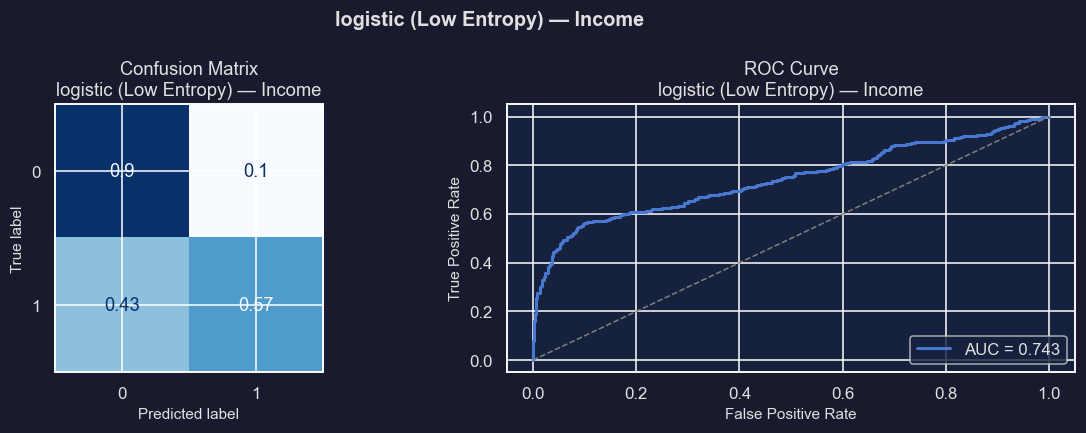


logistic (Low Entropy) — Income
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |  0.767   |
| Precision (0/1) |   nan   |  nan   |  0.768   |
|  Recall (0/1)   |   nan   |  nan   |  0.767   |
|    F1 (0/1)     |   nan   |  nan   |  0.758   |
|     Safety      |   nan   |  nan   |   -1.0   |
|    Balanced     |   nan   |  nan   |  0.628   |
+-----------------+---------+--------+----------+
⚠️ WARNING: Low Entropy set violates safety constraint!


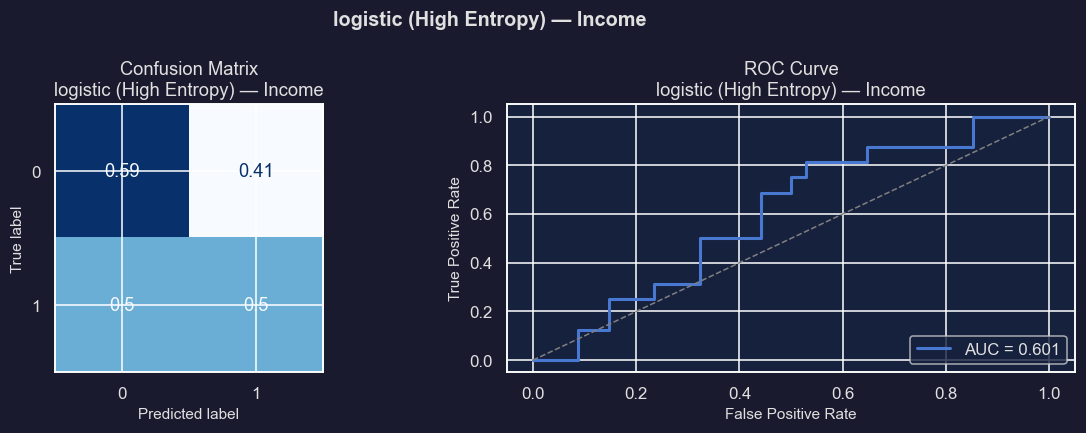


logistic (High Entropy) — Income
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |   0.56   |
| Precision (0/1) |   nan   |  nan   |  0.602   |
|  Recall (0/1)   |   nan   |  nan   |   0.56   |
|    F1 (0/1)     |   nan   |  nan   |  0.573   |
|     Safety      |   nan   |  nan   |   -1.0   |
|    Balanced     |   nan   |  nan   |  0.459   |
+-----------------+---------+--------+----------+
⚠️ WARNING: High Entropy set violates safety constraint!


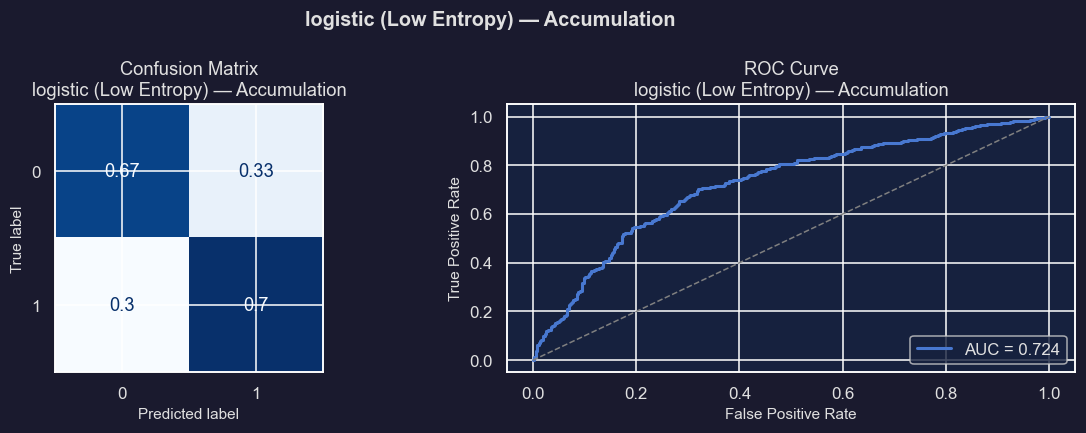


logistic (Low Entropy) — Accumulation
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |  0.689   |
| Precision (0/1) |   nan   |  nan   |  0.689   |
|  Recall (0/1)   |   nan   |  nan   |  0.689   |
|    F1 (0/1)     |   nan   |  nan   |  0.689   |
|     Safety      |   nan   |  nan   |   -1.0   |
|    Balanced     |   nan   |  nan   |  0.703   |
+-----------------+---------+--------+----------+
⚠️ WARNING: Low Entropy set violates safety constraint!


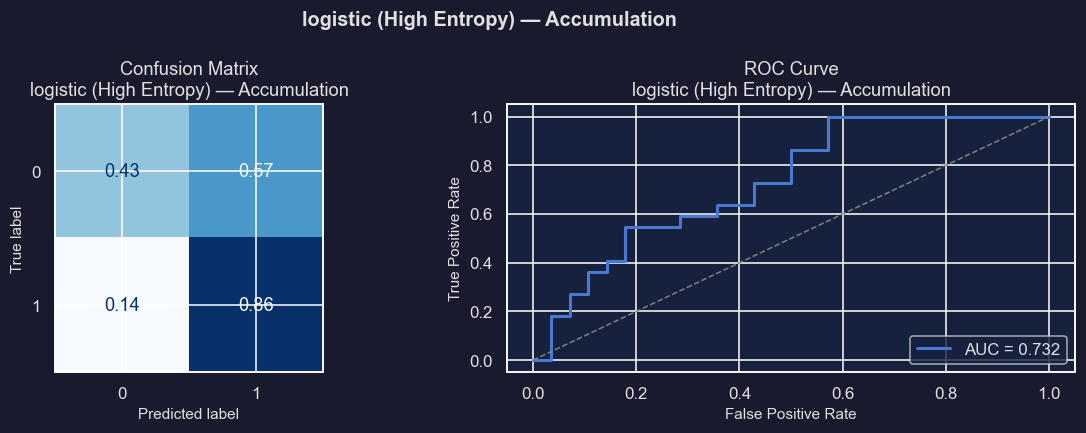


logistic (High Entropy) — Accumulation
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |   0.62   |
| Precision (0/1) |   nan   |  nan   |  0.687   |
|  Recall (0/1)   |   nan   |  nan   |   0.62   |
|    F1 (0/1)     |   nan   |  nan   |  0.606   |
|     Safety      |   nan   |  nan   |   -1.0   |
|    Balanced     |   nan   |  nan   |  0.767   |
+-----------------+---------+--------+----------+
⚠️ WARNING: High Entropy set violates safety constraint!

[XGB]
Income       — clean: 3,800  review: 200
Accumulation — clean: 3,800  review: 200


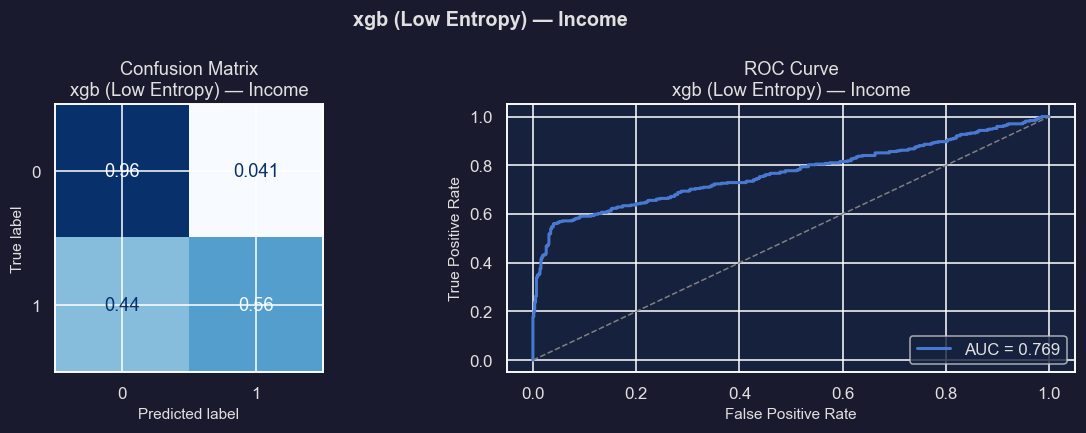


xgb (Low Entropy) — Income
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |  0.804   |
| Precision (0/1) |   nan   |  nan   |  0.822   |
|  Recall (0/1)   |   nan   |  nan   |  0.804   |
|    F1 (0/1)     |   nan   |  nan   |  0.792   |
|     Safety      |   nan   |  nan   |  0.896   |
|    Balanced     |   nan   |  nan   |  0.662   |
+-----------------+---------+--------+----------+


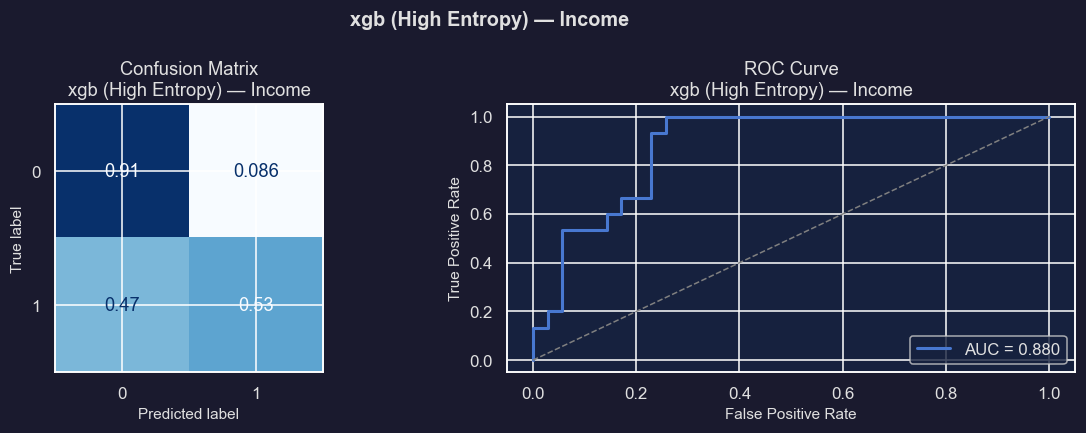


xgb (High Entropy) — Income
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |   0.8    |
| Precision (0/1) |   nan   |  nan   |  0.793   |
|  Recall (0/1)   |   nan   |  nan   |   0.8    |
|    F1 (0/1)     |   nan   |  nan   |   0.79   |
|     Safety      |   nan   |  nan   |  0.727   |
|    Balanced     |   nan   |  nan   |  0.592   |
+-----------------+---------+--------+----------+


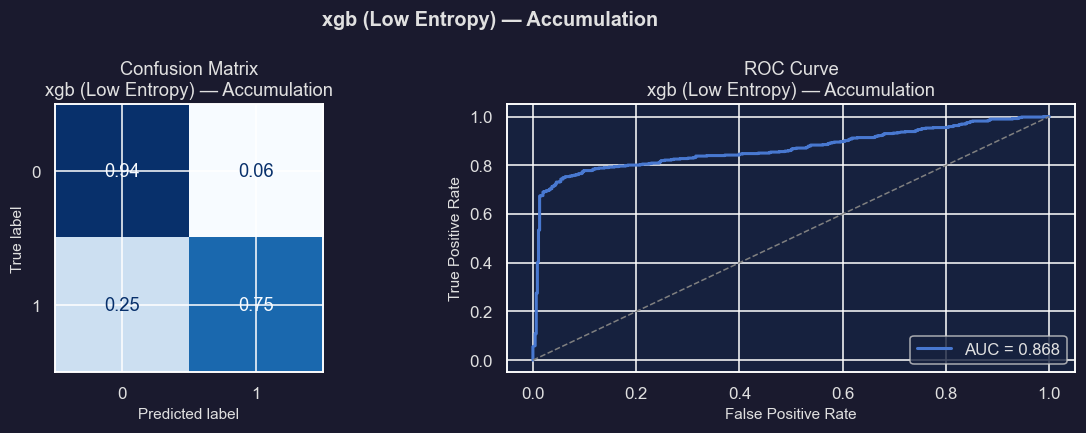


xgb (Low Entropy) — Accumulation
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |  0.842   |
| Precision (0/1) |   nan   |  nan   |  0.857   |
|  Recall (0/1)   |   nan   |  nan   |  0.842   |
|    F1 (0/1)     |   nan   |  nan   |  0.841   |
|     Safety      |   nan   |  nan   |  0.929   |
|    Balanced     |   nan   |  nan   |  0.803   |
+-----------------+---------+--------+----------+


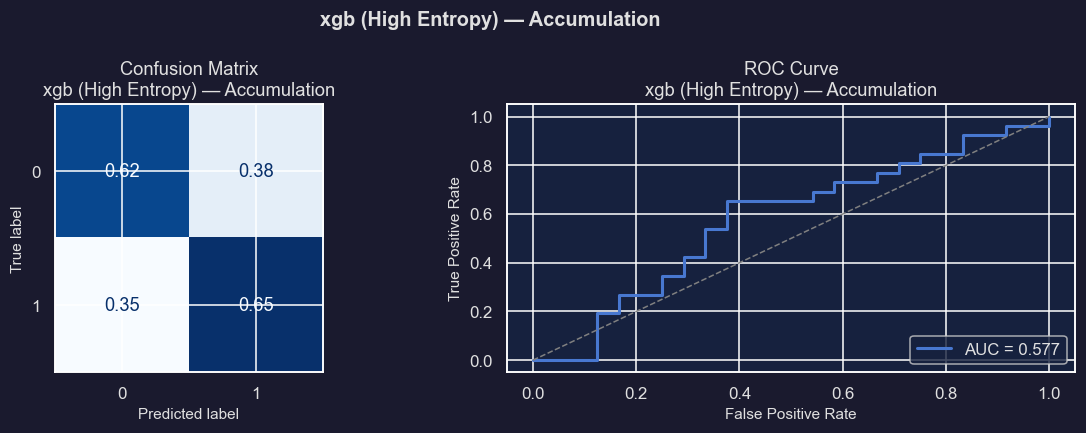


xgb (High Entropy) — Accumulation
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |   0.64   |
| Precision (0/1) |   nan   |  nan   |   0.64   |
|  Recall (0/1)   |   nan   |  nan   |   0.64   |
|    F1 (0/1)     |   nan   |  nan   |   0.64   |
|     Safety      |   nan   |  nan   |   -1.0   |
|    Balanced     |   nan   |  nan   |  0.654   |
+-----------------+---------+--------+----------+
⚠️ WARNING: High Entropy set violates safety constraint!

[KNN]
Income       — clean: 3,800  review: 200
Accumulation — clean: 3,800  review: 200


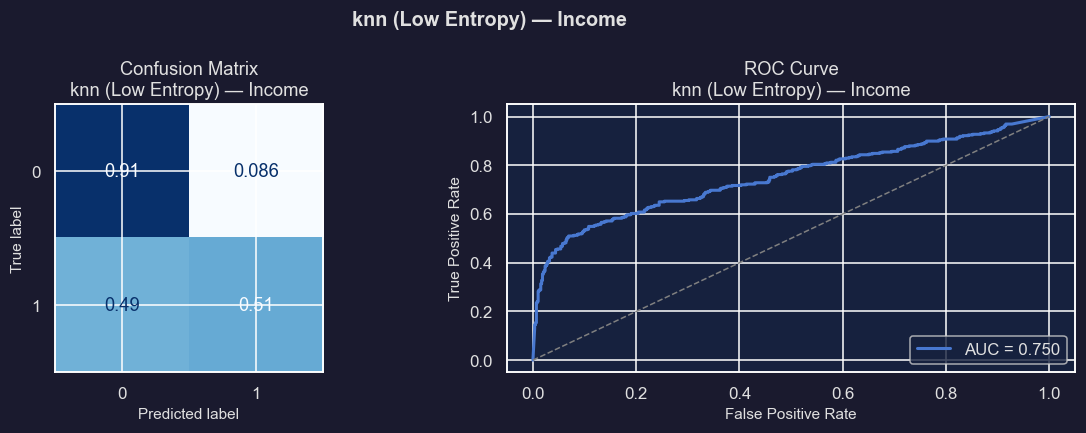


knn (Low Entropy) — Income
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |  0.763   |
| Precision (0/1) |   nan   |  nan   |  0.766   |
|  Recall (0/1)   |   nan   |  nan   |  0.763   |
|    F1 (0/1)     |   nan   |  nan   |   0.75   |
|     Safety      |   nan   |  nan   |  0.782   |
|    Balanced     |   nan   |  nan   |  0.593   |
+-----------------+---------+--------+----------+


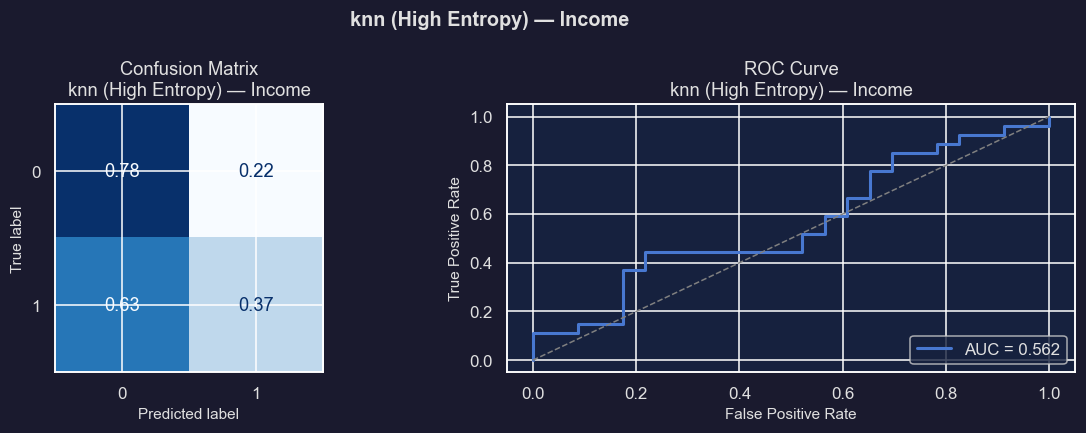


knn (High Entropy) — Income
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |   0.56   |
| Precision (0/1) |   nan   |  nan   |  0.597   |
|  Recall (0/1)   |   nan   |  nan   |   0.56   |
|    F1 (0/1)     |   nan   |  nan   |  0.543   |
|     Safety      |   nan   |  nan   |   -1.0   |
|    Balanced     |   nan   |  nan   |  0.459   |
+-----------------+---------+--------+----------+
⚠️ WARNING: High Entropy set violates safety constraint!


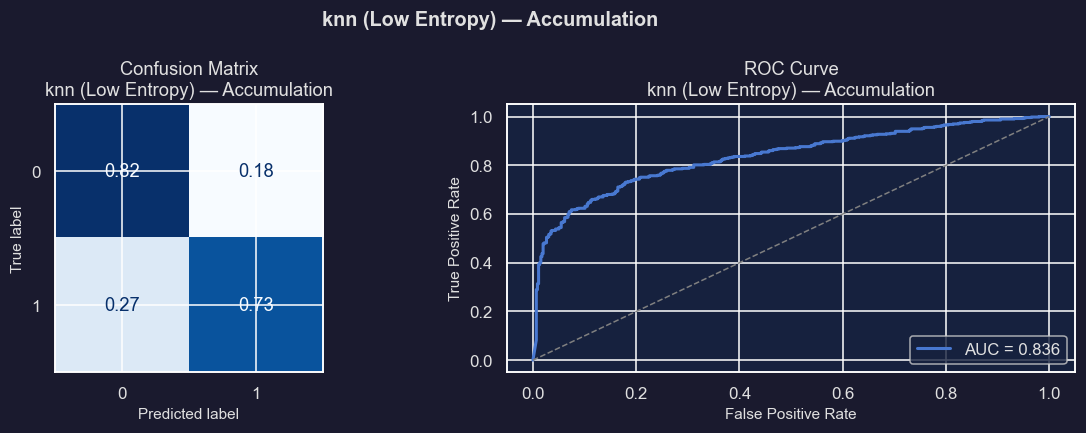


knn (Low Entropy) — Accumulation
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |  0.772   |
| Precision (0/1) |   nan   |  nan   |  0.775   |
|  Recall (0/1)   |   nan   |  nan   |  0.772   |
|    F1 (0/1)     |   nan   |  nan   |  0.771   |
|     Safety      |   nan   |  nan   |   -1.0   |
|    Balanced     |   nan   |  nan   |  0.755   |
+-----------------+---------+--------+----------+
⚠️ WARNING: Low Entropy set violates safety constraint!


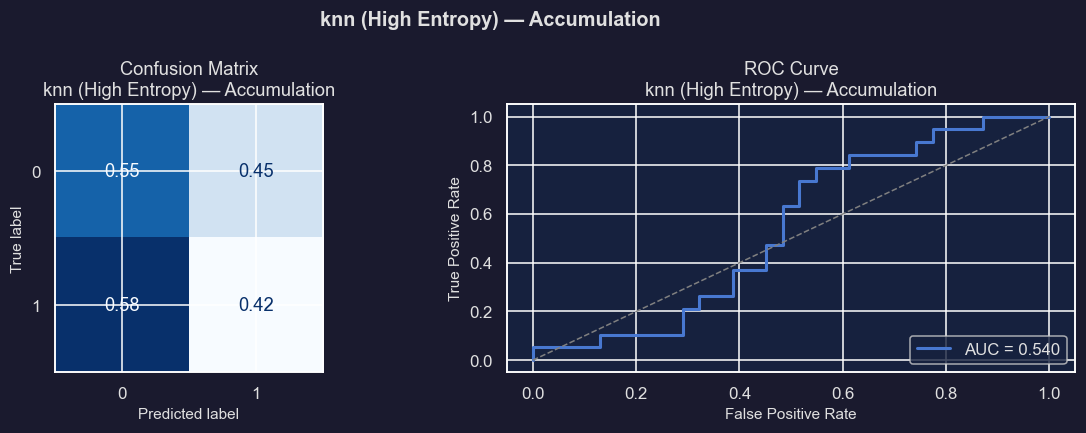


knn (High Entropy) — Accumulation
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |   0.5    |
| Precision (0/1) |   nan   |  nan   |  0.515   |
|  Recall (0/1)   |   nan   |  nan   |   0.5    |
|    F1 (0/1)     |   nan   |  nan   |  0.506   |
|     Safety      |   nan   |  nan   |   -1.0   |
|    Balanced     |   nan   |  nan   |  0.404   |
+-----------------+---------+--------+----------+
⚠️ WARNING: High Entropy set violates safety constraint!

[SVM]
Income       — clean: 3,800  review: 200
Accumulation — clean: 3,800  review: 200


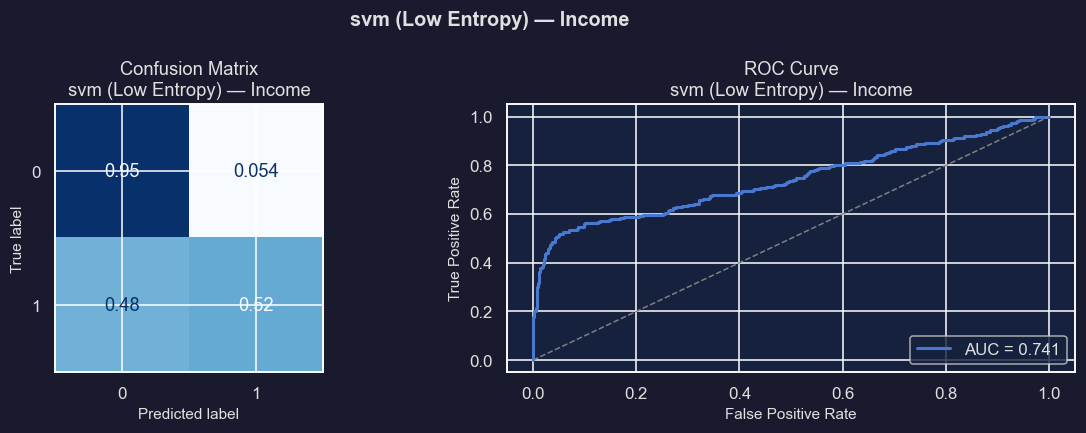


svm (Low Entropy) — Income
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |  0.784   |
| Precision (0/1) |   nan   |  nan   |  0.797   |
|  Recall (0/1)   |   nan   |  nan   |  0.784   |
|    F1 (0/1)     |   nan   |  nan   |  0.769   |
|     Safety      |   nan   |  nan   |  0.853   |
|    Balanced     |   nan   |  nan   |  0.617   |
+-----------------+---------+--------+----------+


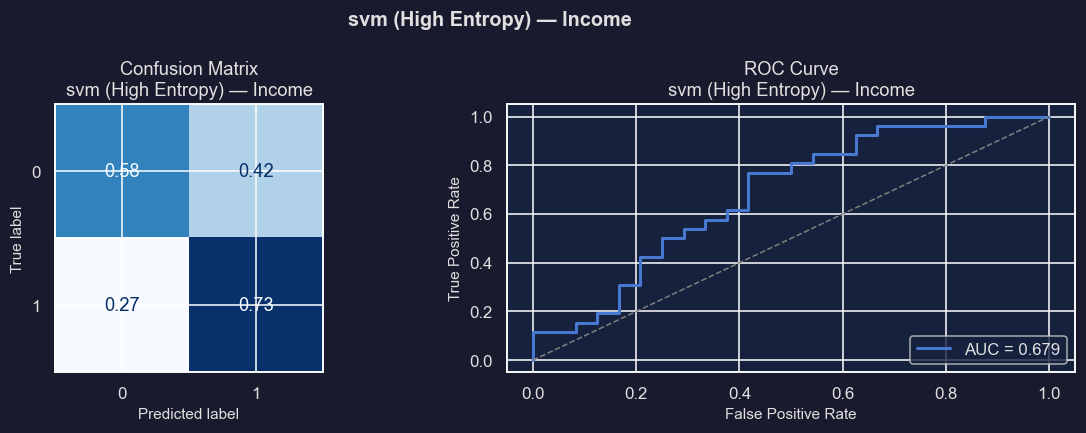


svm (High Entropy) — Income
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |   0.66   |
| Precision (0/1) |   nan   |  nan   |  0.661   |
|  Recall (0/1)   |   nan   |  nan   |   0.66   |
|    F1 (0/1)     |   nan   |  nan   |  0.658   |
|     Safety      |   nan   |  nan   |   -1.0   |
|    Balanced     |   nan   |  nan   |  0.708   |
+-----------------+---------+--------+----------+
⚠️ WARNING: High Entropy set violates safety constraint!


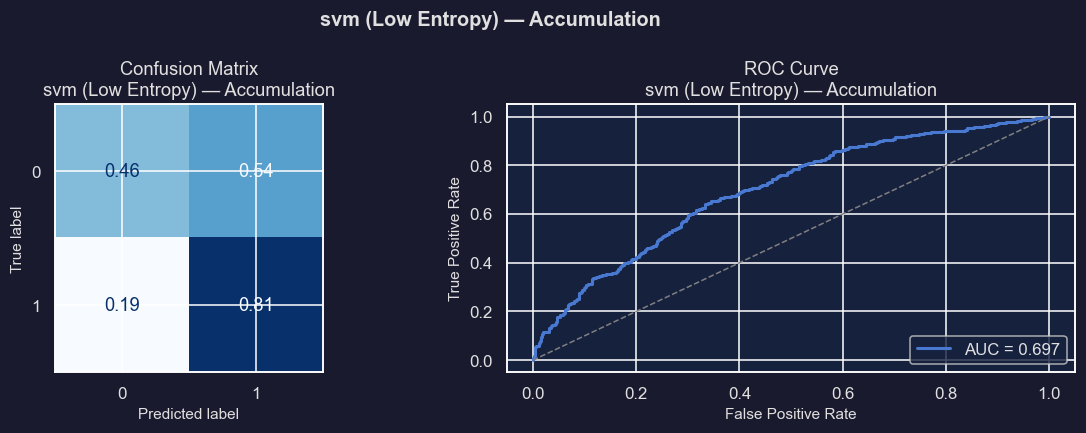


svm (Low Entropy) — Accumulation
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |  0.644   |
| Precision (0/1) |   nan   |  nan   |  0.655   |
|  Recall (0/1)   |   nan   |  nan   |  0.644   |
|    F1 (0/1)     |   nan   |  nan   |  0.632   |
|     Safety      |   nan   |  nan   |   -1.0   |
|    Balanced     |   nan   |  nan   |  0.754   |
+-----------------+---------+--------+----------+
⚠️ WARNING: Low Entropy set violates safety constraint!


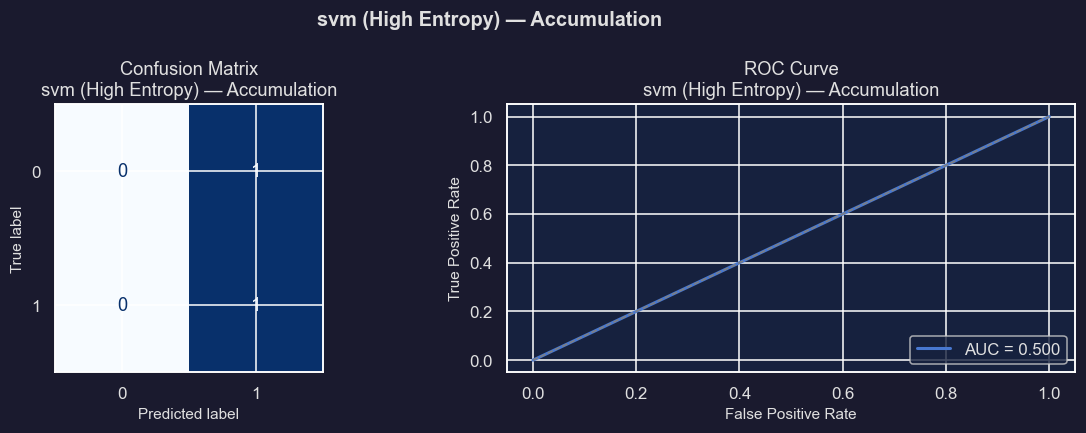


svm (High Entropy) — Accumulation
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |  0.333   |
| Precision (0/1) |   nan   |  nan   |  0.111   |
|  Recall (0/1)   |   nan   |  nan   |  0.333   |
|    F1 (0/1)     |   nan   |  nan   |  0.167   |
|     Safety      |   nan   |  nan   |   -1.0   |
|    Balanced     |   nan   |  nan   |   0.8    |
+-----------------+---------+--------+----------+
⚠️ WARNING: High Entropy set violates safety constraint!

[GNB]
Income       — clean: 3,800  review: 200
Accumulation — clean: 3,800  review: 200


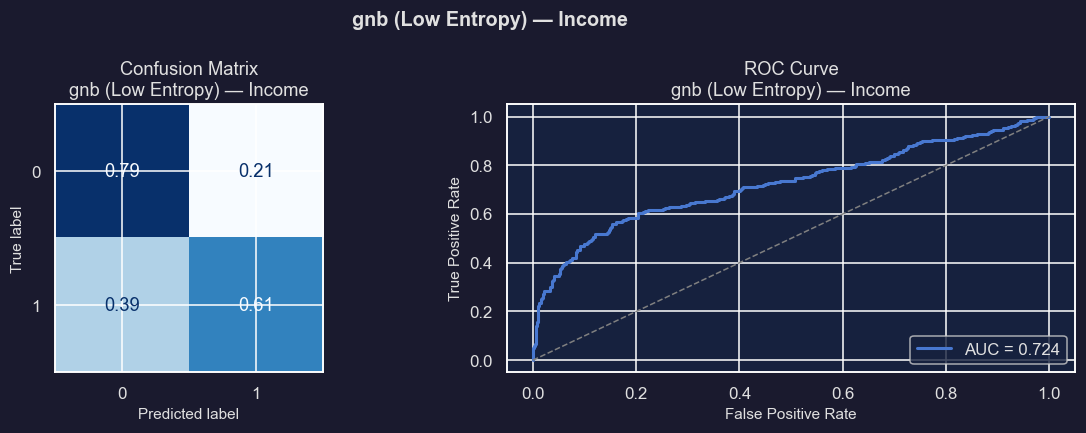


gnb (Low Entropy) — Income
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |  0.718   |
| Precision (0/1) |   nan   |  nan   |  0.715   |
|  Recall (0/1)   |   nan   |  nan   |  0.718   |
|    F1 (0/1)     |   nan   |  nan   |  0.716   |
|     Safety      |   nan   |  nan   |   -1.0   |
|    Balanced     |   nan   |  nan   |  0.618   |
+-----------------+---------+--------+----------+
⚠️ WARNING: Low Entropy set violates safety constraint!


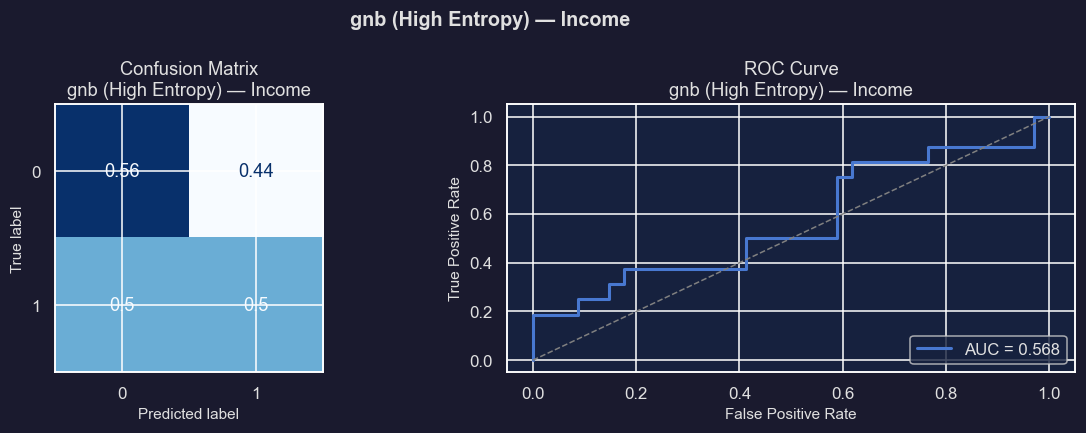


gnb (High Entropy) — Income
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |   0.54   |
| Precision (0/1) |   nan   |  nan   |   0.59   |
|  Recall (0/1)   |   nan   |  nan   |   0.54   |
|    F1 (0/1)     |   nan   |  nan   |  0.555   |
|     Safety      |   nan   |  nan   |   -1.0   |
|    Balanced     |   nan   |  nan   |  0.454   |
+-----------------+---------+--------+----------+
⚠️ WARNING: High Entropy set violates safety constraint!


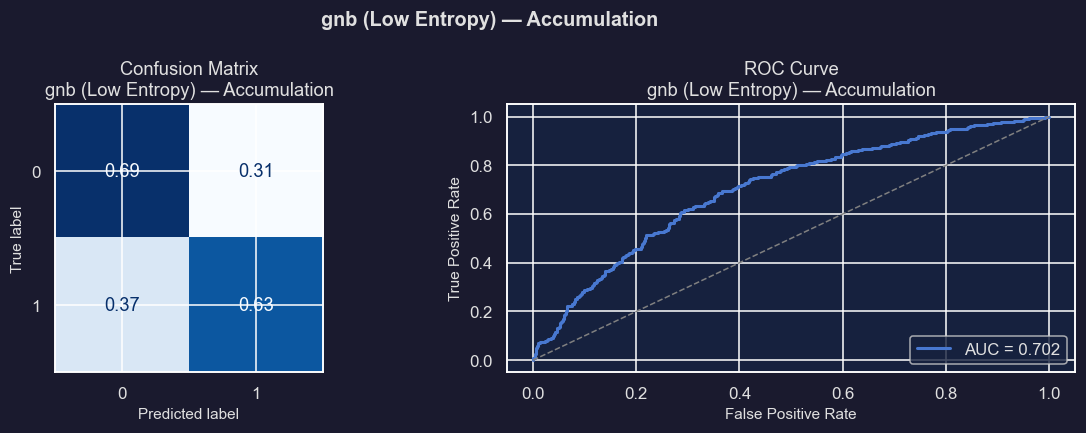


gnb (Low Entropy) — Accumulation
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |  0.657   |
| Precision (0/1) |   nan   |  nan   |  0.658   |
|  Recall (0/1)   |   nan   |  nan   |  0.657   |
|    F1 (0/1)     |   nan   |  nan   |  0.657   |
|     Safety      |   nan   |  nan   |   -1.0   |
|    Balanced     |   nan   |  nan   |  0.644   |
+-----------------+---------+--------+----------+
⚠️ WARNING: Low Entropy set violates safety constraint!


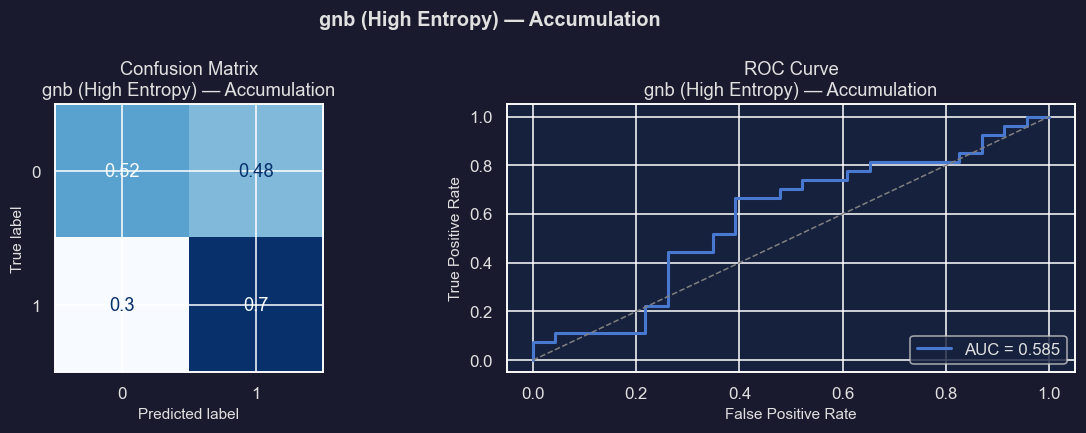


gnb (High Entropy) — Accumulation
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |   0.62   |
| Precision (0/1) |   nan   |  nan   |  0.618   |
|  Recall (0/1)   |   nan   |  nan   |   0.62   |
|    F1 (0/1)     |   nan   |  nan   |  0.617   |
|     Safety      |   nan   |  nan   |   -1.0   |
|    Balanced     |   nan   |  nan   |  0.683   |
+-----------------+---------+--------+----------+
⚠️ WARNING: High Entropy set violates safety constraint!


In [73]:
# STORAGE

entropy_train_splits = {
    "income": {},
    "accum": {},
}
entropy_test_results = {
    "income": {},
    "accum": {},
}

for model_name in MODEL_LIST:

    inc_model = trained_models[f"{model_name}_income"]
    acc_model = trained_models[f"{model_name}_accum"]

    # ENTROPY SPLIT ON TRAIN

    clean_income_train, review_income_train, thr_income_train = split_by_entropy(
        X_train_inc_scaled, y_income_train,
        inc_model.predict_proba(X_train_inc_scaled)[:, 1],
        top_percent=0.05,
    )
    clean_accum_train, review_accum_train, thr_accum_train = split_by_entropy(
        X_train_acc_scaled, y_accum_train,
        acc_model.predict_proba(X_train_acc_scaled)[:, 1],
        top_percent=0.05,
    )

    entropy_train_splits["income"][model_name] = {
        "clean":     clean_income_train,
        "review":    review_income_train,
        "threshold": thr_income_train,
    }
    entropy_train_splits["accum"][model_name] = {
        "clean":     clean_accum_train,
        "review":    review_accum_train,
        "threshold": thr_accum_train,
    }

    print(f"\n[{model_name.upper()}]")
    print(f"Income       — clean: {len(clean_income_train):,}  review: {len(review_income_train):,}")
    print(f"Accumulation — clean: {len(clean_accum_train):,}  review: {len(review_accum_train):,}")

    # ENTROPY DIAGNOSTICS ON TEST

    inc_test_prob = inc_model.predict_proba(X_test_inc_scaled)[:, 1]
    inc_test_pred = (inc_test_prob >= 0.5).astype(int)

    acc_test_prob = acc_model.predict_proba(X_test_acc_scaled)[:, 1]
    acc_test_pred = (acc_test_prob >= 0.5).astype(int)

    inc_test_diagnostics = evaluate_entropy_splits(
        inc_model, X_test_inc_scaled, y_income_test, inc_test_pred, inc_test_prob,
        model_name, "Income", alpha=0.05,
    )
    acc_test_diagnostics = evaluate_entropy_splits(
        acc_model, X_test_acc_scaled, y_accum_test, acc_test_pred, acc_test_prob,
        model_name, "Accumulation", alpha=0.05,
    )

    entropy_test_results["income"][model_name] = {
        "prob":        inc_test_prob,
        "pred":        inc_test_pred,
        "diagnostics": inc_test_diagnostics,
    }
    entropy_test_results["accum"][model_name] = {
        "prob":        acc_test_prob,
        "pred":        acc_test_pred,
        "diagnostics": acc_test_diagnostics,
    }

### Summary of Results

XGBoost is the strongest model overall. Key findings:

- **XGBoost** is the only model that passes the safety constraint on both tasks (Income accuracy: 0.838, Accumulation: 0.844 under low entropy).
- **High entropy** causes all models to degrade to ~40–60% accuracy and fail the safety constraint universally.
- **Accumulation** is harder — Logistic Regression and KNN fail the safety constraint even under low entropy; only XGBoost meets requirements for both targets.

## Stacking Ensemble — Overview

This section implements a **stacking (meta-learning) framework**, where multiple base models are combined into a single, more powerful predictive system.

---

### 🔹 From Individual Models to an Ensemble
Instead of relying on a single model, several trained models are treated as **independent predictors**.
Each model captures different patterns in the data, and the goal is to **combine their strengths while reducing individual weaknesses**.

---

### 🔹 Out-of-Fold (OOF) Predictions — The Core Idea
To train the ensemble safely, the system uses **out-of-fold predictions**:

- Each base model generates predictions on data it **has not seen during training**
- These predictions form a new dataset (the **meta-feature space**)

This is critical because:
- It prevents **data leakage**
- It ensures the meta-model learns from **realistic, unbiased signals**

👉 Conceptually, the base models become **feature generators**, and their predictions become the **inputs** to the next level.

---

### 🔹 Meta-Model Learning (Stacking Layer)
A second-level model (here, an XGBoost meta-model) is trained on the OOF predictions.

Its role is to:
- Learn **how to optimally combine base model outputs**
- Assign **implicit weights** to each model depending on their reliability
- Capture **interactions between model predictions**

This transforms the system from:
> “many independent opinions” → into → **a coordinated decision-maker**

---

### 🔹 Model Importance as Contribution
The meta-model provides **feature importances**, which now represent:

> **How much each base model contributes to the final decision**

This gives interpretability at the ensemble level:
- Strong models receive higher importance
- Weak or redundant models contribute less

---

### 🔹 Test-Time Ensemble Construction
For unseen data:

1. Each base model generates predictions
2. These predictions form the **test meta-feature matrix**
3. The meta-model produces final probabilities

This ensures consistency:
- The meta-model sees the same type of inputs during training and testing

---
This block builds a **hierarchical learning system**:

> Base models learn from data →
> Meta-model learns from base models →
> Final predictions are more robust, accurate, and stable

And most importantly:

> The use of OOF predictions ensures the ensemble is **statistically sound and free from leakage**.

In [74]:
# BUILD WRAPPER LISTS FROM trained_models

models_income = [trained_models[f"{name}_income"] for name in MODEL_LIST]
models_accum  = [trained_models[f"{name}_accum"]  for name in MODEL_LIST]

# GENERATE OOF PREDICTIONS

print("Computing OOF predictions for Income meta-model...")
oof_matrix_income = compute_oof_matrix(models_income, X_train_inc_scaled, y_income_train)

print("\nComputing OOF predictions for Accumulation meta-model...")
oof_matrix_accum = compute_oof_matrix(models_accum, X_train_acc_scaled, y_accum_train)

# FIT META-MODELS VIA ModelFactory

print("\nTuning & Fitting Meta-Models...")
meta_income = ModelFactory.create("xgb")
meta_accum  = ModelFactory.create("xgb")

print("\n[Income] Tuning meta-model...")
meta_income.tune(oof_matrix_income, y_income_train)
print(f"  Best params : {meta_income.best_params}")
print(f"  Best score  : {meta_income.tuning_results['best_score']:.4f}")

print("\n[Accum] Tuning meta-model...")
meta_accum.tune(oof_matrix_accum, y_accum_train)
print(f"  Best params : {meta_accum.best_params}")
print(f"  Best score  : {meta_accum.tuning_results['best_score']:.4f}")

# train() will automatically apply best_params_ (set inside _store_tuning)
meta_income.train(oof_matrix_income, y_income_train)
meta_accum.train(oof_matrix_accum,   y_accum_train)

print("\nMeta-Model Feature Importances (Base Model Contributions):")

print("\n[Income] Model Importances:")

# Use feature importance
for wrapper, imp in zip(models_income, meta_income.trained_model.feature_importances_):
    print(f"  {wrapper.name:20s} — Importance: {imp:>7.4f}")

print("\n[Accum] Model Importances:")
for wrapper, imp in zip(models_accum, meta_accum.trained_model.feature_importances_):
    print(f"  {wrapper.name:20s} — Importance: {imp:>7.4f}")

# BUILD TEST MATRICES & GENERATE ENSEMBLE PROBABILITIES

test_matrix_income = build_test_matrix(models_income, X_test_inc_scaled)
test_matrix_accum  = build_test_matrix(models_accum,  X_test_acc_scaled)

ensemble_income_prob = meta_income.predict_proba(test_matrix_income)[:, 1]
ensemble_accum_prob  = meta_accum.predict_proba(test_matrix_accum)[:, 1]

print("\nEnsemble statistics:")
print(f"  Income — mean: {ensemble_income_prob.mean():.3f}  std: {ensemble_income_prob.std():.3f}")
print(f"  Accum  — mean: {ensemble_accum_prob.mean():.3f}  std: {ensemble_accum_prob.std():.3f}")

print("\n✓ Stacking ensemble fitted safely on OOF train signals, evaluated on TEST set.")

Computing OOF predictions for Income meta-model...

Computing OOF predictions for Accumulation meta-model...

Tuning & Fitting Meta-Models...

[Income] Tuning meta-model...
  Best params : {'colsample_bytree': 0.7740389971646935, 'gamma': 0.016781676451174125, 'learning_rate': 0.19107409250298252, 'max_depth': 2, 'min_child_weight': 9, 'n_estimators': 260, 'reg_alpha': 1.78923016327074, 'reg_lambda': 0.19207664806242017, 'subsample': 0.5192655463157296}
  Best score  : 0.6975

[Accum] Tuning meta-model...
  Best params : {'colsample_bytree': 0.8997767208035865, 'gamma': 2.190145932204617, 'learning_rate': 0.04843382015645565, 'max_depth': 5, 'min_child_weight': 9, 'n_estimators': 387, 'reg_alpha': 2.1208903623034105, 'reg_lambda': 1.99787449871348, 'subsample': 0.6765419227639857}
  Best score  : 0.7907

Meta-Model Feature Importances (Base Model Contributions):

[Income] Model Importances:
  LogisticRegression   — Importance:  0.0948
  XGBoost              — Importance:  0.3717
  KNN 

### Ensemble Evaluation

This section assesses the **ensemble model** on unseen data by converting probabilities into decisions (threshold = 0.5) and analyzing performance.

- **Diagnostics**: Confusion Matrix (errors) + ROC Curve (overall discrimination)
- **Metrics**: Accuracy, Precision, Recall, F1, AUC, Balanced Score, Safety
- **Scope**: Evaluated separately for **Income** and **Accumulation**

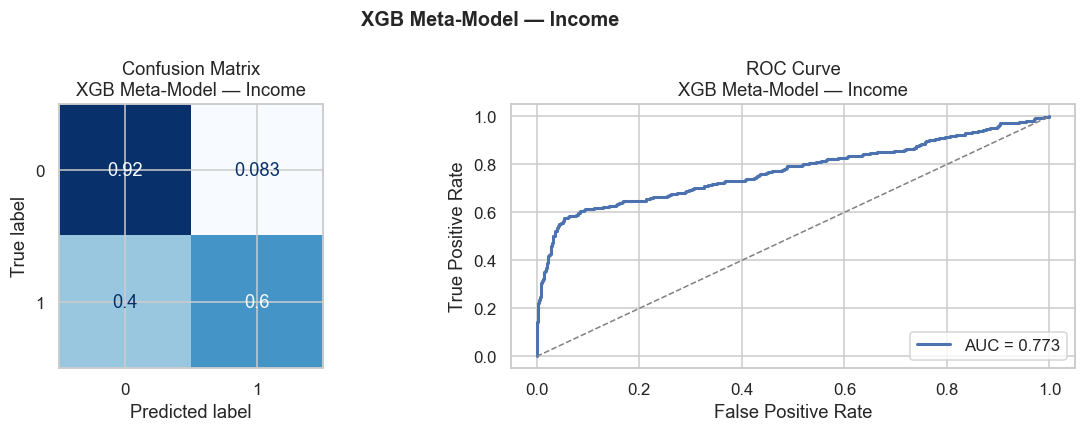

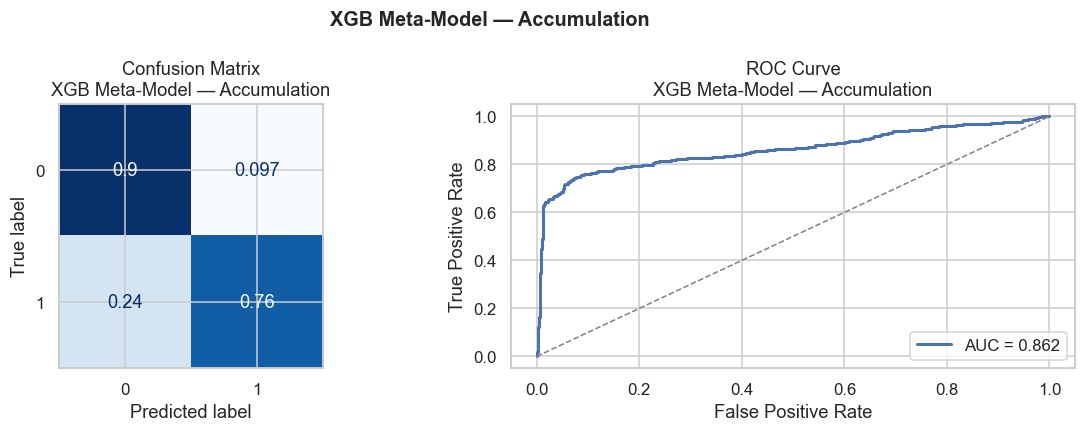


Ensemble Results — XGB Meta-Model

             Accuracy Precision (0/1)   Recall (0/1)       F1 (0/1)    AUC Safety Balanced Score
Target                                                                                          
Income          0.794   0.785 / 0.818  0.917 / 0.596  0.846 / 0.690  0.773  0.818          0.663
Accumulation    0.830   0.782 / 0.892  0.903 / 0.760  0.838 / 0.821  0.862  0.892          0.800


In [88]:
# ENSEMBLE PREDICTIONS (threshold 0.5)

ensemble_income_pred = (ensemble_income_prob >= 0.35).astype(int)
ensemble_accum_pred  = (ensemble_accum_prob  >= 0.40).astype(int)

# DIAGNOSTICS PLOTS (Confusion Matrix + ROC)

plot_model_diagnostics(
    y_income_test.values, ensemble_income_pred, ensemble_income_prob,
    model_name="XGB Meta-Model", feature_type="Income"
)

plot_model_diagnostics(
    y_accum_test.values, ensemble_accum_pred, ensemble_accum_prob,
    model_name="XGB Meta-Model", feature_type="Accumulation"
)

# RESULTS TABLE

rows = []
for label, y_true, y_pred, y_prob in [
    ("Income",        y_income_test.values, ensemble_income_pred, ensemble_income_prob),
    ("Accumulation",  y_accum_test.values,  ensemble_accum_pred,  ensemble_accum_prob),
]:
    acc, prec, rec, f1, safety, balanced = compute_metrics(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    rows.append({
        "Target":           label,
        "Accuracy":         f"{acc:.3f}",
        "Precision (0/1)":  f"{prec[0]:.3f} / {prec[1]:.3f}",
        "Recall (0/1)":     f"{rec[0]:.3f} / {rec[1]:.3f}",
        "F1 (0/1)":         f"{f1[0]:.3f} / {f1[1]:.3f}",
        "AUC":              f"{roc_auc:.3f}",
        "Safety":           f"{safety:.3f}" if safety != -1.0 else " UNSAFE",
        "Balanced Score":   f"{balanced:.3f}",
    })

results_df = pd.DataFrame(rows).set_index("Target")
print("\nEnsemble Results — XGB Meta-Model\n")
print(results_df.to_string())

---
## 9. Recommendations

`generate_recommendations` applies business logic on top of model probabilities:

1. **Entropy guardrail** — most uncertain → `ADVISOR_REVIEW`
2. **Threshold check**
3. **Conflict resolution** — if both thresholds met, higher probability wins

Outcomes: `INCOME` · `ACCUMULATION` · `NO_ACTION` · `ADVISOR_REVIEW`

## Optimized Threshold Strategy

### Income Threshold (0.35)

**Reason:**
At the default 0.5 threshold, the model was overly conservative (Precision: 0.911, Recall: 0.609), meaning it missed ~39% of clients who actually needed an Income product.

**Impact:**
Lowering the threshold to 0.35 significantly boosts Recall. This captures more valid marketing leads and maximizes potential revenue, with only a slight drop in Precision.

---

### Accumulation Threshold (0.40)

**Reason:**
The model already performed well and was fairly balanced at the 0.5 mark (Precision: 0.916, Recall: 0.745).

**Impact:**
Reducing the threshold to 0.45 pushes Recall closer to ~80%, expanding campaign reach while maintaining high confidence and keeping false positives under control.

---

### Entropy Guardrail (95th Percentile)

**Reason:**
Regulatory compliance requirement (MiFID / IDD "Best Interest" rules).

**Impact:**
Acts as a safety net: the top 5% most uncertain predictions are excluded from automated assignment and routed to a human advisor, preventing potentially inappropriate recommendations.

In [90]:
# FULL DATASET SCALING
X_full_inc_scaled = pd.DataFrame(
    scaler_inc.transform(feature_df[NUMERICAL_FEATURES]),
    columns=NUMERICAL_FEATURES,
    index=feature_df.index
)

X_full_acc_scaled = pd.DataFrame(
    scaler_acc.transform(feature_df[NUMERICAL_FEATURES]),
    columns=NUMERICAL_FEATURES,
    index=feature_df.index
)


for col in CATEGORICAL_FEATURES:
    X_full_inc_scaled[col] = feature_df[col].values
    X_full_acc_scaled[col] = feature_df[col].values

# COLLECT FULL-DATASET PROBABILITIES

def build_full_matrix(model_outputs, X_full, trained_models, suffix):
    return np.column_stack([
        trained_models[f"{m['name']}_{suffix}"].predict_proba(X_full)[:, 1]
        for m in model_outputs
    ])


full_matrix_income = build_full_matrix(
    model_outputs_income, X_full_inc_scaled, trained_models, "income"
)

full_matrix_accum = build_full_matrix(
    model_outputs_accum, X_full_acc_scaled, trained_models, "accum"
)

ensemble_income_prob_full = meta_income.predict_proba(full_matrix_income)[:, 1]
ensemble_accum_prob_full  = meta_accum.predict_proba(full_matrix_accum)[:, 1]


# BUILD RECOMMENDATION DATAFRAME

df_recommendations = pd.DataFrame({
    "income_prob": ensemble_income_prob_full,
    "accum_prob":  ensemble_accum_prob_full,
}, index=feature_df.index)


# GENERATE RECOMMENDATIONS

df_recommendations = generate_recommendations(
    df_recommendations,
    inc_col="income_prob",
    acc_col="accum_prob",
    inc_threshold=0.35,
    acc_threshold=0.40,
    entropy_quantile=0.95,
)


print(f"Total records scored: {len(df_recommendations):,}")

print("\nRecommendation distribution:")
print(df_recommendations["recommendation"].value_counts())

print(f"\nFlagged for advisor review: {df_recommendations['review_flag'].sum():,} "
      f"({df_recommendations['review_flag'].mean():.1%})")

print("\nSample output:")
print(df_recommendations[["income_prob", "accum_prob", "recommendation", "review_flag"]].head(10))

Total records scored: 5,000

Recommendation distribution:
recommendation
NO_ACTION         1861
ACCUMULATION      1689
INCOME             963
ADVISOR_REVIEW     487
Name: count, dtype: int64

Flagged for advisor review: 487 (9.7%)

Sample output:
   income_prob  accum_prob recommendation  review_flag
0     0.921856    0.264994         INCOME        False
1     0.135913    0.202688      NO_ACTION        False
2     0.232491    0.205242      NO_ACTION        False
3     0.110139    0.990870   ACCUMULATION        False
4     0.954514    0.987002   ACCUMULATION        False
5     0.224075    0.216186      NO_ACTION        False
6     0.918845    0.214812         INCOME        False
7     0.840034    0.155959         INCOME        False
8     0.159765    0.985108   ACCUMULATION        False
9     0.086100    0.242569      NO_ACTION        False


---
## 10. Export

Exports per-customer probabilities, recommendations, and review flags to `model_predictions.xlsx`.

In [77]:
# EXPORT
output_path = "model_predictions.xlsx"

# Attach ground truth labels for reference
df_export = df_recommendations.copy()
df_export["y_income"] = income_series.values
df_export["y_accum"]  = accum_series.values

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    df_export.to_excel(writer, sheet_name="recommendations", index=True)

print(f"Saved → {output_path}  ({len(df_export):,} rows)")

Saved → model_predictions.xlsx  (5,000 rows)


### Make the recommendation system

In [78]:


# LOAD PRODUCTS & SPLIT BY TARGET
products_df = pd.read_excel("products_output.xlsx")

# Type 0 = Income, Type 1 = Accumulation. Sort them by Risk ascending.
income_products = products_df[products_df['Type'] == 0].sort_values('Risk').copy()
accum_products  = products_df[products_df['Type'] == 1].sort_values('Risk').copy()

# PREPARE THE DATASET

# Bring over the unscaled RiskPropensity from your original feature_df
global_min_risk = feature_df['RiskPropensity'].min()
global_max_risk = feature_df['RiskPropensity'].max()

print(f"Global Risk Range: [{global_min_risk:.3f}, {global_max_risk:.3f}]")

# We attach RiskPropensity to the recommendation dataframe you already built
final_campaign_df = df_recommendations.copy()
final_campaign_df['RiskPropensity'] = feature_df['RiskPropensity']

# 4. MAP RISK BUCKETS TO PRODUCT IDs
inc_bins, inc_labels = get_risk_bins_and_labels(income_products, global_min_risk, global_max_risk)
acc_bins, acc_labels = get_risk_bins_and_labels(accum_products, global_min_risk, global_max_risk)

# pd.cut automatically assigns the correct ProductID based on where the client's risk falls in the bins
final_campaign_df['Income_ProductID'] = pd.cut(final_campaign_df['RiskPropensity'], bins=inc_bins, labels=inc_labels)
final_campaign_df['Accum_ProductID']  = pd.cut(final_campaign_df['RiskPropensity'], bins=acc_bins, labels=acc_labels)


final_campaign_df['Assigned_ProductID'] = final_campaign_df.apply(finalize_nba, axis=1)

# TRANSLATE IDs TO READABLE NAMES

product_dictionary = {
    1.0: 'Balanced Mutual Fund',
    2.0: 'Income Conservative Unit-Linked (Life Insurance)',
    3.0: 'Fixed Income Mutual Fund',
    4.0: 'Balanced High Dividend Mutual Fund',
    5.0: 'Balanced Mutual Fund',
    6.0: 'Defensive Flexible Allocation Unit-Linked (Life Insurance)',
    7.0: 'Aggressive Flexible Allocation Unit-Linked (Life Insurance)',
    8.0: 'Balanced Flexible Allocation Unit-Linkled (Life Insurance)',
    9.0: 'Cautious Allocation Segregated Account',
    10.0: 'Fixed Income Segregated Account',
    11.0: 'Total Return Aggressive Allocation Segregated Account',
    "HUMAN_ADVISOR": "Flagged for Human Advisor",
    "NO_ACTION": "No Immediate Need"
}

final_campaign_df['Product_Name'] = final_campaign_df['Assigned_ProductID'].map(product_dictionary)

# FINAL CAMPAIGN SUMMARY
print("\n--- Final Campaign Assignments ---")
print(final_campaign_df['Product_Name'].value_counts())

print("\n--- Sample Output ---")
print(final_campaign_df[['recommendation', 'RiskPropensity', 'Product_Name']].head(10))

Global Risk Range: [0.025, 0.883]

--- Final Campaign Assignments ---
Product_Name
No Immediate Need                                              1873
Cautious Allocation Segregated Account                          650
Balanced High Dividend Mutual Fund                              522
Flagged for Human Advisor                                       487
Balanced Mutual Fund                                            464
Defensive Flexible Allocation Unit-Linked (Life Insurance)      283
Income Conservative Unit-Linked (Life Insurance)                263
Balanced Flexible Allocation Unit-Linkled (Life Insurance)      196
Fixed Income Segregated Account                                 123
Aggressive Flexible Allocation Unit-Linked (Life Insurance)      80
Fixed Income Mutual Fund                                         55
Total Return Aggressive Allocation Segregated Account             4
Name: count, dtype: int64

--- Sample Output ---
  recommendation  RiskPropensity  \
0         INCOME

✔ Results successfully saved to final_campaign_recommendations.xlsx


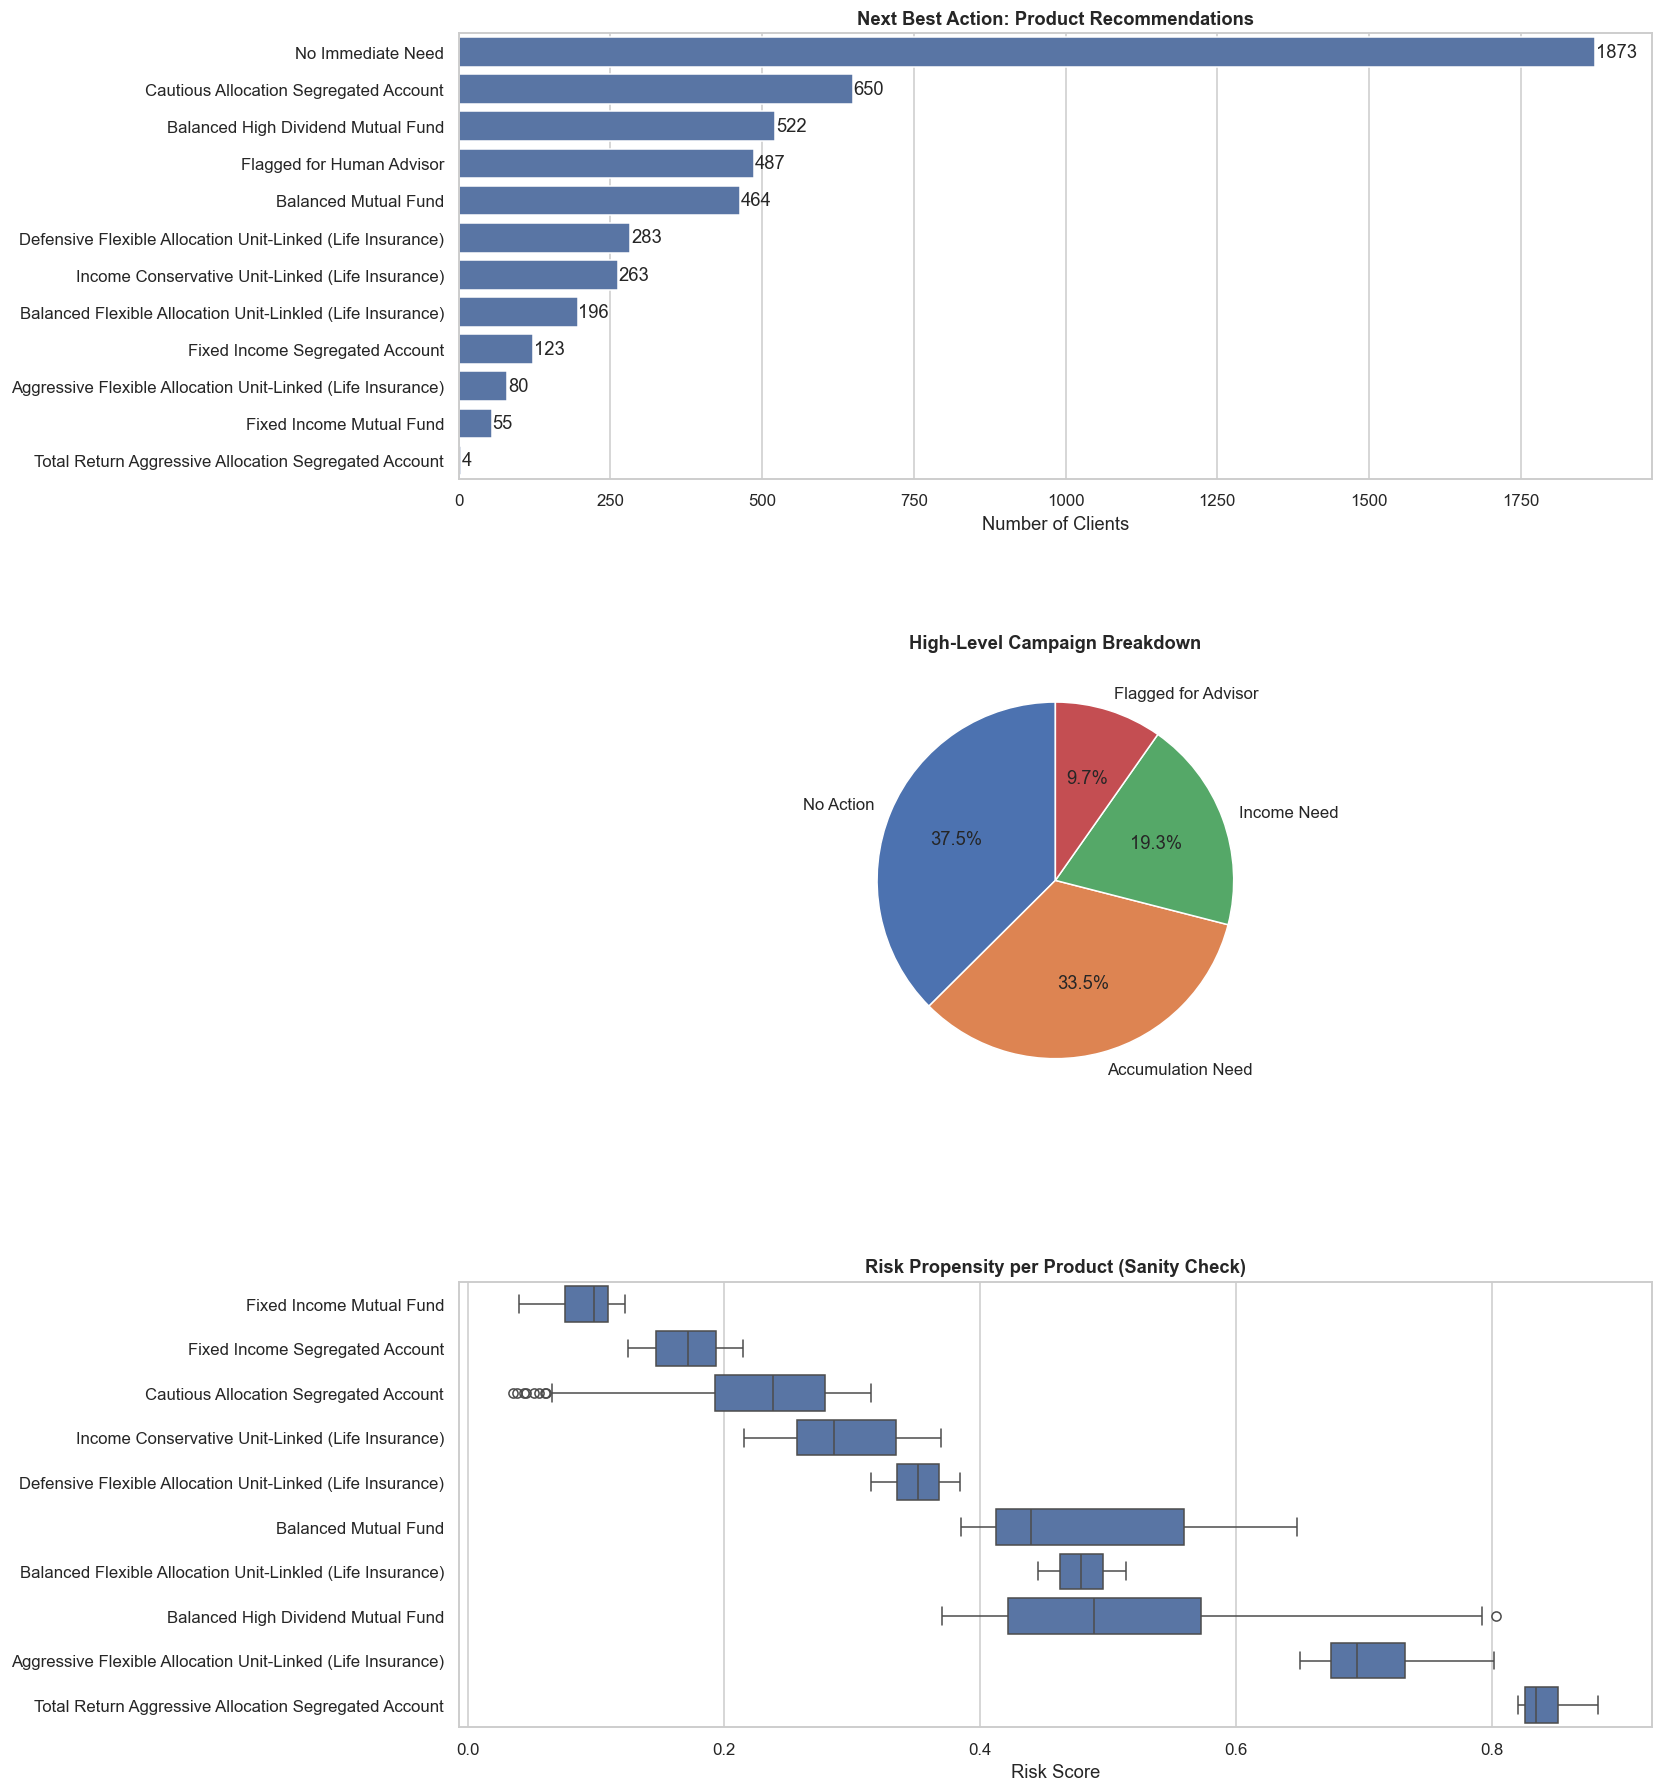

In [79]:
# SAVE RESULTS

output_filename = "final_campaign_recommendations.xlsx"
final_campaign_df.to_excel(output_filename, index=True)

print(f"✔ Results successfully saved to {output_filename}")

# VISUALIZATION
plot_full_dashboard(final_campaign_df)